# EDA: ST Education, Employment, and Poverty Across High-ST States

## Main Question

**How do differences in educational outcomes among Scheduled Tribe populations relate to employment and poverty across high-ST states in India, and which states require different policy priorities?**

## Core Supporting Questions

1. How do ST literacy and literacy gaps describe long-term educational exclusion?
2. Do states with stronger ST schooling participation, measured by GER, also have lower dropout and lower ST poverty?
3. Are enrolment and GER enough to indicate educational progress, or do dropout rates tell a different story?
4. Is the literacy gap more informative than ST literacy alone in explaining disadvantage?
5. Are there states where educational indicators look reasonable, but employment or poverty outcomes remain weak?
6. Does MGNREG unmet demand reflect deeper livelihood distress among ST households?

## Additional Questions

7. Are scholarship-supported states seeing lower secondary dropout among ST students?
8. Do states with high ST schooling participation still depend heavily on MGNREG?
9. Does gender parity in enrolment translate into better female literacy and work outcomes?
10. Does secondary dropout appear to be a stronger warning signal of poverty and weak labour outcomes than literacy alone?
11. Do high-ST-share states systematically perform worse, or do outcomes vary substantially?
12. Do states with high concentrations of ST villages show different education and livelihood outcomes?
13. Are there gender-specific disadvantages hidden behind state averages?

In [1]:
from pathlib import Path
import math
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

OUTPUTS = ROOT / "outputs"
DB_PATH = OUTPUTS / "st_education_project.sqlite"

plt.rcParams["figure.figsize"] = (8.5, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

print("Project root:", ROOT)

Project root: C:\Users\yuvra\OneDrive\Desktop\spring 2026\DSM\Final


## Rebuild Data and EDA Outputs

The raw files remain unchanged. This cell rebuilds the cleaned tables and derived outputs before the notebook reads them.

In [2]:
import scripts.build_project_data as build_project_data
import scripts.run_policy_eda as run_policy_eda

build_project_data.main()
run_policy_eda.main()

Processed 17 datasets
Wrote cleaned CSVs to outputs\cleaned
Wrote analysis outputs to outputs\analysis
Wrote SQLite database to outputs\st_education_project.sqlite


Wrote EDA tables to outputs\eda\tables
Wrote EDA figures to outputs\eda\figures
Wrote EDA report to outputs\eda\eda_policy_report.md


## Load Main Tables

In [3]:
high_st = pd.read_csv(OUTPUTS / "analysis" / "state_analysis_dataset_high_st_states.csv").copy()
all_states = pd.read_csv(OUTPUTS / "analysis" / "state_analysis_dataset_all_states.csv").copy()
inventory = pd.read_csv(OUTPUTS / "analysis" / "data_inventory.csv")

# Keep notebook logic conservative. Clean only what is needed for readable plots.
for col in ["ger_classes_i_viii", "ger_classes_ix_x", "ger_classes_xi_xii"]:
    clean_col = f"{col}_clean"
    high_st[clean_col] = high_st[col].where(high_st[col].between(0, 500))
    all_states[clean_col] = all_states[col].where(all_states[col].between(0, 500))

for col in [
    "ger_classes_ix_x_boys",
    "ger_classes_ix_x_girls",
    "ger_classes_xi_xii_boys",
    "ger_classes_xi_xii_girls",
    "ger_classes_i_viii_girls",
]:
    if col in high_st.columns:
        clean_col = f"{col}_clean"
        high_st[clean_col] = high_st[col].where(high_st[col].between(0, 500))
        all_states[clean_col] = all_states[col].where(all_states[col].between(0, 500))

for col in ["ger_classes_ix_x_gpi", "ger_classes_xi_xii_gpi", "ger_classes_i_viii_gpi"]:
    if col in high_st.columns:
        clean_col = f"{col}_clean"
        high_st[clean_col] = high_st[col].where(high_st[col].between(0, 3))
        all_states[clean_col] = all_states[col].where(all_states[col].between(0, 3))

for col in [
    "ger_latest_secondary_total",
    "ger_latest_secondary_girls",
    "ger_latest_higher_secondary_total",
    "ger_latest_higher_secondary_girls",
]:
    if col in high_st.columns:
        clean_col = f"{col}_clean"
        high_st[clean_col] = high_st[col].where(high_st[col].between(0, 500))
        all_states[clean_col] = all_states[col].where(all_states[col].between(0, 500))

for col in ["gpi_secondary", "gpi_higher_secondary"]:
    if col in high_st.columns:
        clean_col = f"{col}_clean"
        high_st[clean_col] = high_st[col].where(high_st[col].between(0, 3))
        all_states[clean_col] = all_states[col].where(all_states[col].between(0, 3))

high_st["female_literacy_gap_pct"] = (
    high_st["tribe_weighted_literacy_male_pct"] - high_st["tribe_weighted_literacy_female_pct"]
)
all_states["female_literacy_gap_pct"] = (
    all_states["tribe_weighted_literacy_male_pct"] - all_states["tribe_weighted_literacy_female_pct"]
)

high_st["villages_gt50_per_100k_st_pop"] = (
    high_st["tribal_villages_gt_50_count"] / high_st["st_population"] * 100000
)
all_states["villages_gt50_per_100k_st_pop"] = (
    all_states["tribal_villages_gt_50_count"] / all_states["st_population"] * 100000
)
for label, col in [
    ("gt75", "tribal_villages_gt_75_count"),
    ("gt90", "tribal_villages_gt_90_count"),
    ("all_st", "tribal_villages_100_pct_count"),
]:
    high_st[f"villages_{label}_per_100k_st_pop"] = high_st[col] / high_st["st_population"] * 100000
    all_states[f"villages_{label}_per_100k_st_pop"] = all_states[col] / all_states["st_population"] * 100000

print(f"High-ST states: {high_st.shape[0]} rows")
print(f"All-state master table: {all_states.shape[0]} rows")

High-ST states: 19 rows
All-state master table: 34 rows


In [4]:
def corr_frame(df, x_cols, y_cols, sample_name):
    rows = []
    for x in x_cols:
        for y in y_cols:
            subset = df[[x, y]].dropna()
            if len(subset) < 4:
                continue
            r, p = stats.pearsonr(subset[x], subset[y])
            rows.append(
                {
                    "sample": sample_name,
                    "x": x,
                    "y": y,
                    "n": len(subset),
                    "pearson_r": round(float(r), 4),
                    "pearson_p": round(float(p), 4),
                    "abs_r": round(abs(float(r)), 4),
                }
            )
    return pd.DataFrame(rows).sort_values("abs_r", ascending=False).reset_index(drop=True)


def corr_pairs(df, pairs, sample_name):
    rows = []
    for x, y in pairs:
        subset = df[[x, y]].dropna()
        if len(subset) < 4:
            continue
        r, p = stats.pearsonr(subset[x], subset[y])
        rows.append(
            {
                "sample": sample_name,
                "x": x,
                "y": y,
                "n": len(subset),
                "pearson_r": round(float(r), 4),
                "pearson_p": round(float(p), 4),
                "abs_r": round(abs(float(r)), 4),
            }
        )
    return pd.DataFrame(rows).sort_values("abs_r", ascending=False).reset_index(drop=True)


def compare_predictors(df, predictors, outcomes):
    rows = []
    for outcome in outcomes:
        scores = []
        for predictor in predictors:
            subset = df[[predictor, outcome]].dropna()
            if len(subset) < 4:
                continue
            r, p = stats.pearsonr(subset[predictor], subset[outcome])
            scores.append((predictor, len(subset), r, p, abs(r)))
        if not scores:
            continue
        scores = sorted(scores, key=lambda x: x[4], reverse=True)
        best = scores[0]
        second = scores[1] if len(scores) > 1 else None
        rows.append(
            {
                "outcome": outcome,
                "stronger_predictor": best[0],
                "n": best[1],
                "pearson_r": round(best[2], 4),
                "pearson_p": round(best[3], 4),
                "runner_up": second[0] if second else None,
                "runner_up_abs_r": round(second[4], 4) if second else None,
            }
        )
    return pd.DataFrame(rows)


def show_scatter(df, x, y, title, x_label, y_label, color="#34699a"):
    plot_df = df[["state", x, y]].dropna()
    fig, ax = plt.subplots(figsize=(8.2, 5.9))
    ax.scatter(plot_df[x], plot_df[y], color=color, s=52)
    for _, row in plot_df.iterrows():
        ax.annotate(row["state"], (row[x], row[y]), fontsize=7, xytext=(3, 2), textcoords="offset points")
    if len(plot_df) >= 4 and plot_df[x].nunique() > 1 and plot_df[y].nunique() > 1:
        r, p = stats.pearsonr(plot_df[x], plot_df[y])
        if p < 0.001:
            p_text = "p < 0.001"
        else:
            p_text = f"p = {p:.3f}"
        corr_text = f"Pearson r = {r:.2f}, {p_text}, n = {len(plot_df)}"
    else:
        corr_text = f"Pearson r not shown; n = {len(plot_df)}"
    if len(plot_df) >= 4 and plot_df[x].nunique() > 1:
        m, b = np.polyfit(plot_df[x], plot_df[y], 1)
        xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
        ax.plot(xs, m * xs + b, color="#444444", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.text(
        0.5,
        -0.18,
        corr_text,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#d0d0d0", "alpha": 0.95},
    )
    fig.subplots_adjust(bottom=0.22)
    plt.show()


def show_distribution_grid(df, columns, title):
    cols = [c for c in columns if c in df.columns]
    ncols = 2
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        series = df[col].dropna()
        ax.hist(series, bins=min(8, max(4, len(series) // 2)), color="#4d7c8a", edgecolor="white")
        if len(series) > 0:
            ax.axvline(series.median(), color="#8f3f3f", linestyle="--", linewidth=1, label="Median")
            ax.legend(frameon=False, fontsize=8)
        ax.set_title(col)
    for ax in axes[len(cols):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


def show_rank_bar(df, value_col, title, xlabel, ascending=True, top_n=10, color="#697a21"):
    plot_df = df[["state", value_col]].dropna().sort_values(value_col, ascending=ascending).head(top_n)
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(plot_df) + 2))
    ax.barh(plot_df["state"], plot_df[value_col], color=color)
    if ascending:
        ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.show()


def show_abs_correlation_compare(df, predictors, outcomes, title):
    rows = []
    for outcome in outcomes:
        for predictor in predictors:
            subset = df[[predictor, outcome]].dropna()
            if len(subset) < 4:
                continue
            r, _ = stats.pearsonr(subset[predictor], subset[outcome])
            rows.append({"outcome": outcome, "predictor": predictor, "abs_r": abs(r)})
    frame = pd.DataFrame(rows)
    pivot = frame.pivot(index="outcome", columns="predictor", values="abs_r")
    pivot.plot(kind="barh", figsize=(9, 5.5), color=["#34699a", "#a65d03", "#8f3f3f"][: len(pivot.columns)])
    plt.title(title)
    plt.xlabel("Absolute Pearson correlation")
    plt.ylabel("")
    plt.legend(frameon=False)
    plt.show()

## Data Used, In Plain English

The analysis uses cleaned NDAP-based datasets for ST literacy, literacy gap, enrolment, GER, dropout, poverty, labour outcomes, MGNREG distress, ST population share, village concentration, district low female literacy, and tribe-level literacy summaries. It also adds official UDISE+/OGD policy-support files for latest ST GER, ST Gender Parity Index, and ST scholarship release/utilization. MGNREG 100-plus-days indicators are derived from the existing MGNREG table.

In [5]:
inventory[["short_name", "level", "years", "key_variables", "notes"]].rename(
    columns={
        "short_name": "dataset",
        "level": "data_level",
        "years": "year_coverage",
        "key_variables": "main_variables",
        "notes": "how_used",
    }
)

,dataset,data_level,year_coverage,main_variables,how_used
0,literacy,state-year,"1991, 2001, 2011","total literacy, ST literacy, literacy gap",Core education attainment dataset.
1,enrolment_st,state-year,2010,ST enrolment by stage and gender,Includes derived totals and female shares.
2,high_st_share,state-year,2011,"ST share in state population, state share of national ST population",Defines high-ST-share states.
3,sc_st_residence,state-year-residence,2011,"SC population, ST population by rural/urban residence",Useful for demographic scale and rural/urban distribution.
4,tribal_villages,state-year,"2001, 2011",villages above ST concentration thresholds,"Raw metadata labels UOM as percentage, but values behave like counts."
5,mgnreg_st,state-year,2013,"MGNREG job cards, work received, unmet demand, average days",Filtered to Scheduled Tribe and rural households.
6,ger_st,state-year-gender-class,2013,GER by gender and class group,Raw filename is truncated by Windows path limits.
7,ger_st_latest,state-year-gender-level,NaN,latest ST GER by school level and gender,Additional UDISE+ 2023-24 dataset used to strengthen schooling participation and gender questions.
8,gpi_st,state-academic-year-level,NaN,ST gender parity index by school level,Additional UDISE+ 2021-22 dataset used to test whether enrolment parity translates into female outcomes.
9,scholarships_st,state-year-scheme,NaN,pre-matric and post-matric ST scholarship release and utilization,Additional policy-support dataset; amounts are in Rs lakh.


## Coverage Caveat

Poverty is the biggest missing-data problem. GER also needs care because some historical GER values are ratio-style and can exceed 100, so the notebook uses cleaned GER fields for visual work.

In [6]:
coverage = pd.read_csv(OUTPUTS / "eda" / "tables" / "data_quality_core_variable_coverage.csv")
coverage.query(
    "table == 'high_st_master' and column in ['st_literacy_rate_pct','literacy_gap_pct','dropout_upper_primary_pct','dropout_secondary_pct','ger_classes_i_viii','ger_classes_ix_x','ger_latest_secondary_total','gpi_secondary','scholarship_total_release_2023_24_lakh_per_100k_st_pop','employment_lfpr_person_per_1000','employment_wpr_person_per_1000','employment_pu_person_per_1000','st_bpl_mean_pct','mgnreg_sought_not_received_per_1000','mgnreg_work_100_plus_days_per_1000','low_literacy_district_count']"
)[["column", "non_missing", "missing", "missing_pct", "min", "median", "max"]].sort_values("missing_pct", ascending=False)

,column,non_missing,missing,missing_pct,min,median,max
55,low_literacy_district_count,7,12,63.16,1.00,6.000000,15.000000
47,st_bpl_mean_pct,9,10,52.63,9.65,40.150000,51.600000
31,st_literacy_rate_pct,18,1,5.26,50.60,68.900000,91.700000
32,literacy_gap_pct,18,1,5.26,0.10,8.750000,20.600000
43,scholarship_total_release_2023_24_lakh_per_100k_st_pop,18,1,5.26,0.00,233.320259,840.494169
48,employment_lfpr_person_per_1000,18,1,5.26,377.00,456.000000,620.000000
49,employment_wpr_person_per_1000,18,1,5.26,362.00,453.000000,620.000000
50,employment_pu_person_per_1000,18,1,5.26,0.00,8.500000,47.000000
35,dropout_upper_primary_pct,19,0,0.00,0.00,5.370000,14.020000
36,dropout_secondary_pct,19,0,0.00,0.00,12.670000,33.120000


## Distribution EDA

Before asking relationship questions, it helps to see how the variables are distributed across high-ST states.

In [7]:
high_st[[
    "st_literacy_rate_pct",
    "literacy_gap_pct",
    "dropout_upper_primary_pct",
    "dropout_secondary_pct",
    "ger_classes_i_viii_clean",
    "ger_classes_ix_x_clean",
    "ger_latest_secondary_total_clean",
    "gpi_secondary_clean",
    "employment_wpr_person_per_1000",
    "employment_pu_person_per_1000",
    "st_bpl_mean_pct",
    "mgnreg_sought_not_received_per_1000",
    "mgnreg_work_100_plus_days_per_1000",
    "scholarship_total_release_2023_24_lakh_per_100k_st_pop",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
st_literacy_rate_pct,18.0,68.905556,13.515197,50.60,57.600000,68.900000,79.100000,91.700000
literacy_gap_pct,18.0,8.066667,7.501686,0.10,0.575000,8.750000,15.025000,20.600000
dropout_upper_primary_pct,19.0,5.164211,3.664192,0.00,2.680000,5.370000,6.930000,14.020000
dropout_secondary_pct,19.0,13.241053,7.699347,0.00,9.275000,12.670000,17.195000,33.120000
ger_classes_i_viii_clean,18.0,127.427778,34.968335,80.60,103.475000,119.850000,149.925000,214.600000
ger_classes_ix_x_clean,18.0,59.327778,22.658457,29.70,48.625000,51.850000,72.550000,126.700000
ger_latest_secondary_total_clean,19.0,72.642105,14.091696,53.80,61.650000,70.700000,82.600000,100.200000
gpi_secondary_clean,19.0,1.052632,0.107333,0.90,1.000000,1.000000,1.100000,1.300000
employment_wpr_person_per_1000,18.0,438.944444,64.427316,362.00,385.250000,453.000000,464.250000,620.000000
employment_pu_person_per_1000,18.0,14.111111,13.965878,0.00,4.250000,8.500000,18.750000,47.000000


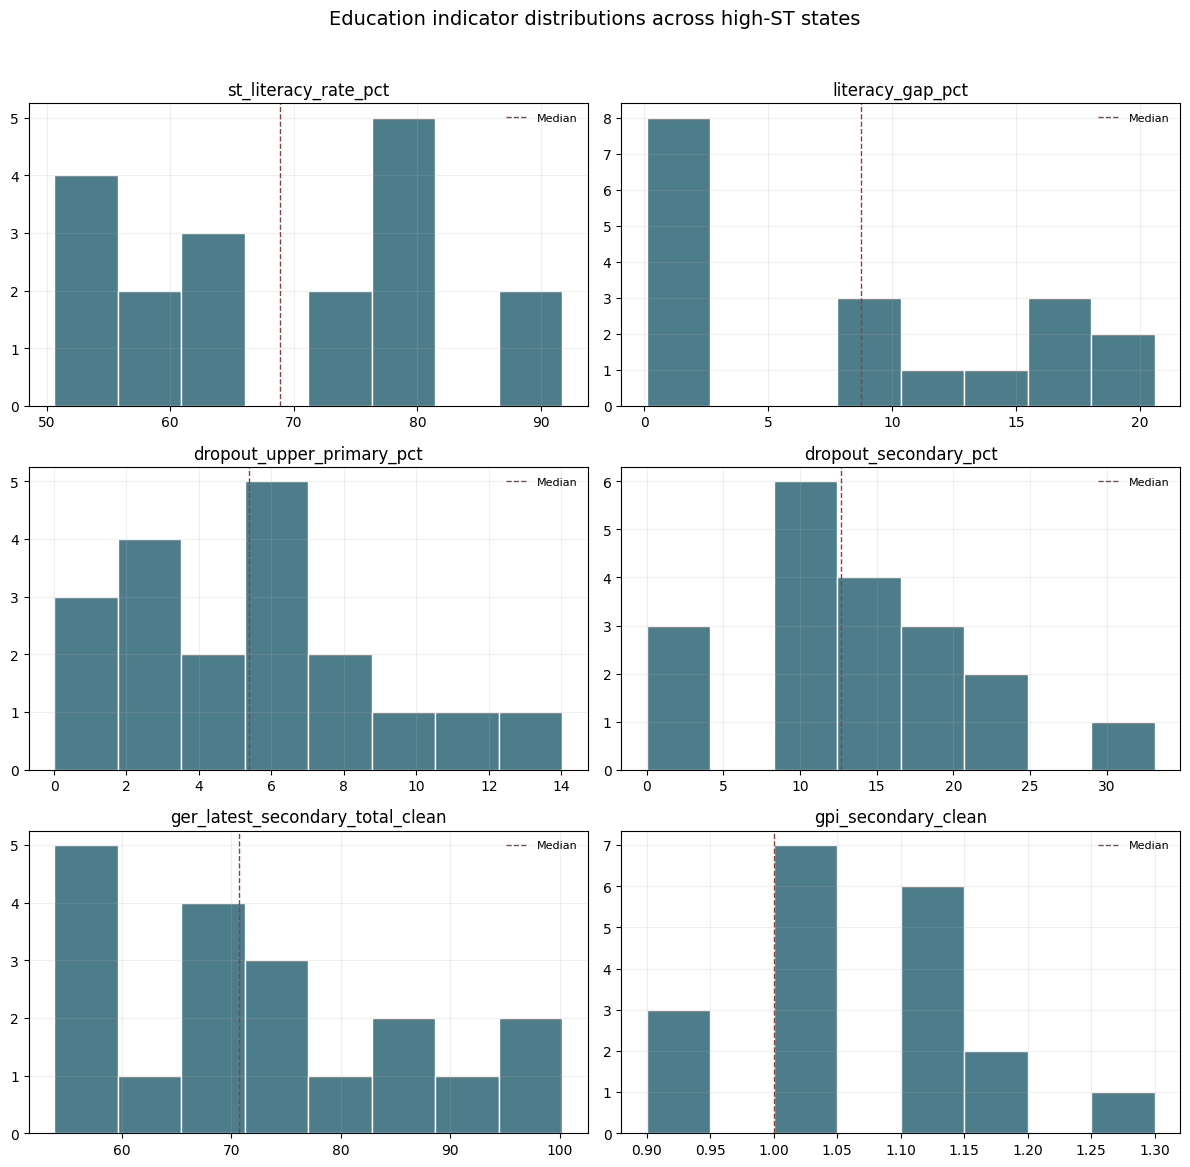

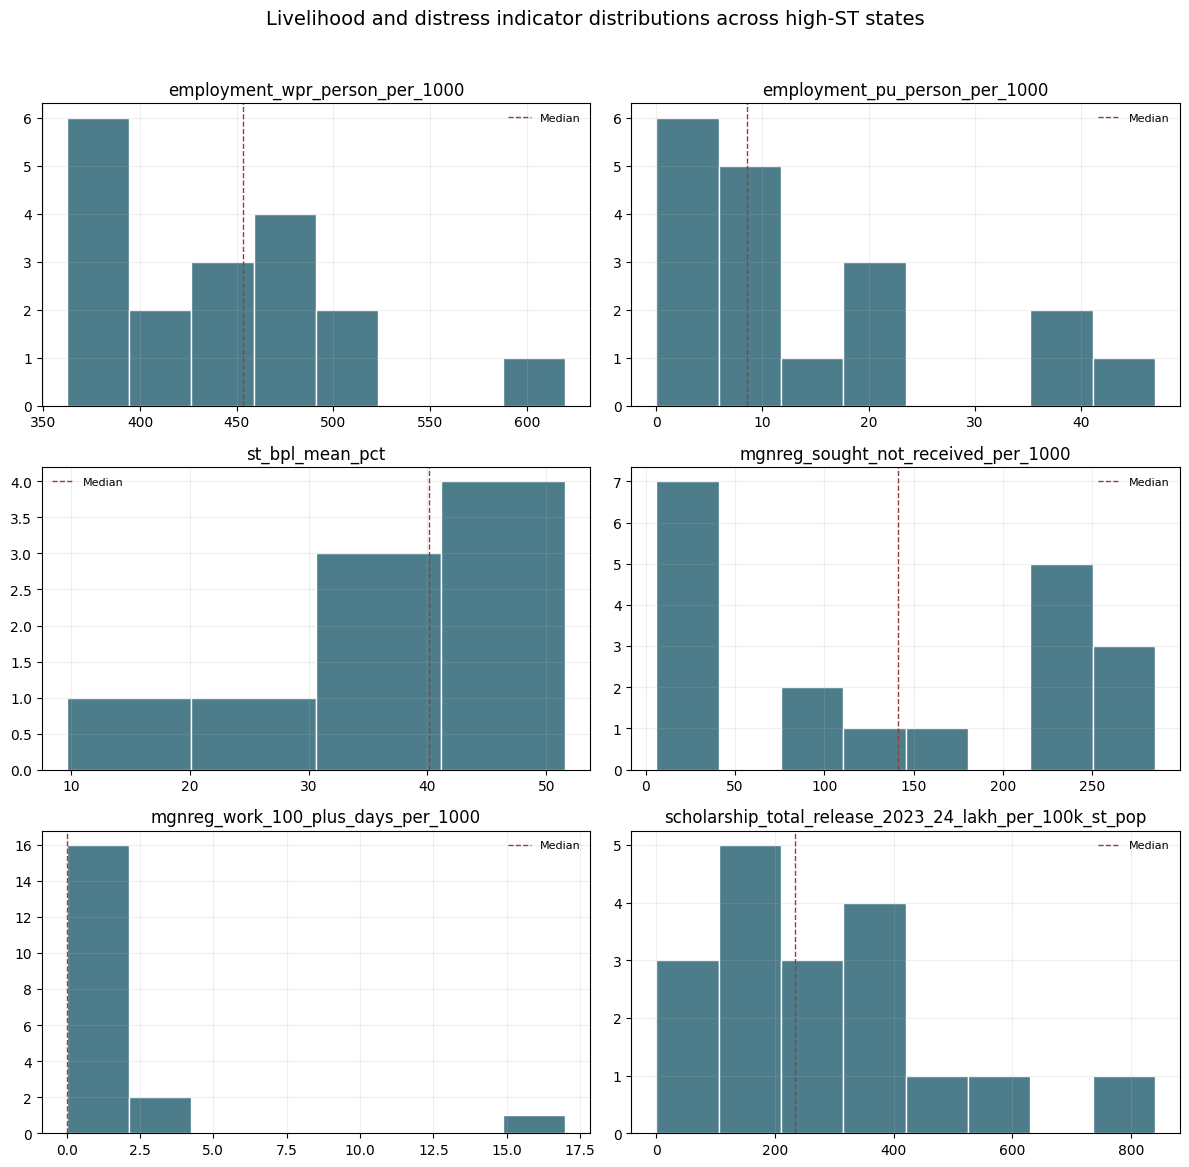

In [8]:
show_distribution_grid(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct", "dropout_upper_primary_pct", "dropout_secondary_pct", "ger_latest_secondary_total_clean", "gpi_secondary_clean"],
    "Education indicator distributions across high-ST states",
)

show_distribution_grid(
    high_st,
    ["employment_wpr_person_per_1000", "employment_pu_person_per_1000", "st_bpl_mean_pct", "mgnreg_sought_not_received_per_1000", "mgnreg_work_100_plus_days_per_1000", "scholarship_total_release_2023_24_lakh_per_100k_st_pop"],
    "Livelihood and distress indicator distributions across high-ST states",
)

## Q1. How Do ST Literacy And Literacy Gaps Describe Long-Term Educational Exclusion?

Literacy is not the same as current schooling quality. It mainly tells us whether people have basic reading and writing ability. In this project, literacy is used as a **long-term attainment and exclusion indicator**, while GER and dropout are used as the schooling-pipeline indicators.

In [9]:
q1 = corr_frame(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct"],
    [
        "employment_lfpr_person_per_1000",
        "employment_wpr_person_per_1000",
        "employment_pu_person_per_1000",
        "st_bpl_mean_pct",
    ],
    "high_st_states",
)
q1

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,st_literacy_rate_pct,employment_pu_person_per_1000,18,0.6177,0.0063,0.6177
1,high_st_states,literacy_gap_pct,employment_wpr_person_per_1000,18,0.5387,0.0211,0.5387
2,high_st_states,literacy_gap_pct,employment_pu_person_per_1000,18,-0.4900,0.0390,0.4900
3,high_st_states,literacy_gap_pct,employment_lfpr_person_per_1000,18,0.4853,0.0412,0.4853
4,high_st_states,st_literacy_rate_pct,employment_wpr_person_per_1000,18,-0.4766,0.0455,0.4766
5,high_st_states,st_literacy_rate_pct,employment_lfpr_person_per_1000,18,-0.3873,0.1123,0.3873
6,high_st_states,literacy_gap_pct,st_bpl_mean_pct,9,0.3275,0.3896,0.3275
7,high_st_states,st_literacy_rate_pct,st_bpl_mean_pct,9,-0.0652,0.8676,0.0652


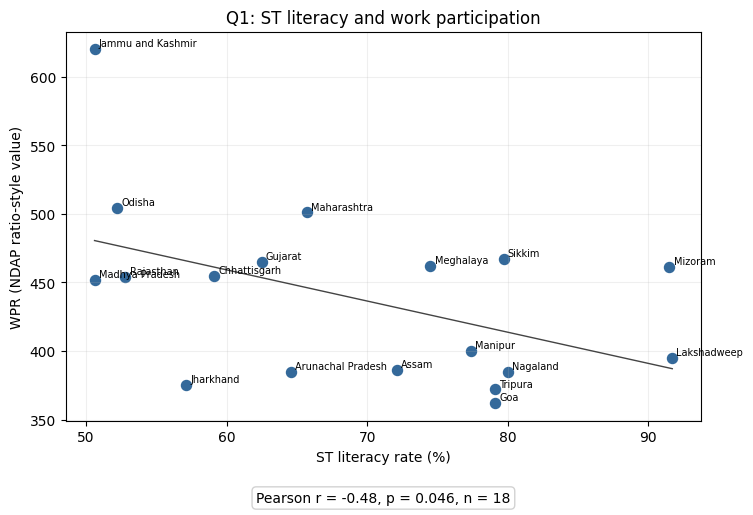

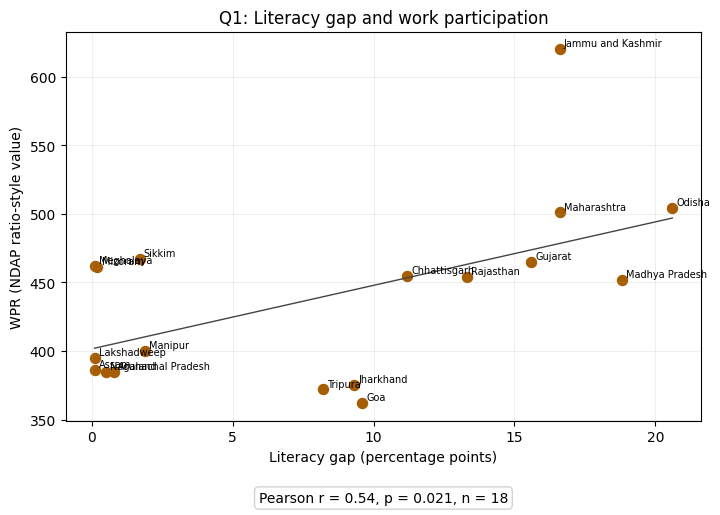

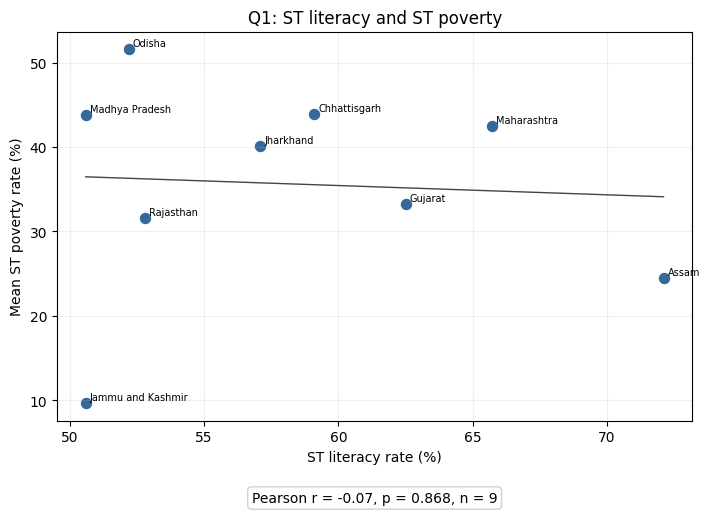

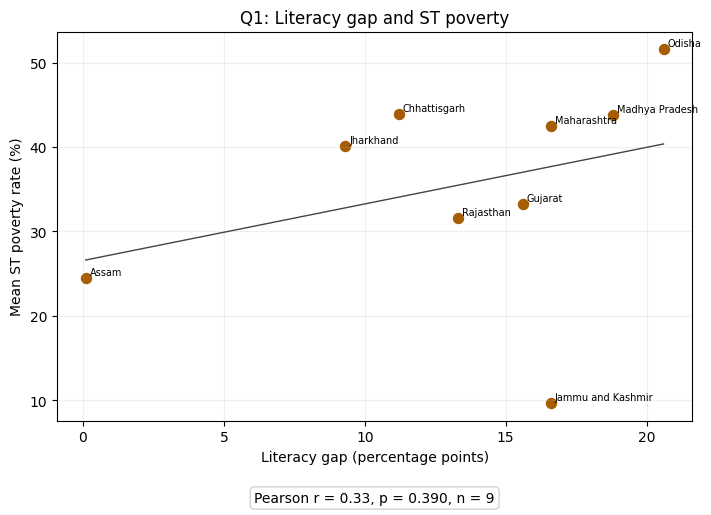

In [10]:
show_scatter(high_st, "st_literacy_rate_pct", "employment_wpr_person_per_1000", "Q1: ST literacy and work participation", "ST literacy rate (%)", "WPR (NDAP ratio-style value)")
show_scatter(high_st, "literacy_gap_pct", "employment_wpr_person_per_1000", "Q1: Literacy gap and work participation", "Literacy gap (percentage points)", "WPR (NDAP ratio-style value)", color="#a65d03")
show_scatter(high_st, "st_literacy_rate_pct", "st_bpl_mean_pct", "Q1: ST literacy and ST poverty", "ST literacy rate (%)", "Mean ST poverty rate (%)")
show_scatter(high_st, "literacy_gap_pct", "st_bpl_mean_pct", "Q1: Literacy gap and ST poverty", "Literacy gap (percentage points)", "Mean ST poverty rate (%)", color="#a65d03")

**Reading Q1:** literacy and the literacy gap are useful for showing long-term exclusion, but they should not be treated as complete measures of educational progress. The current schooling question needs GER and dropout.

## Q2. Do States With Stronger ST Schooling Participation Also Have Lower Dropout And Lower ST Poverty?

This is the more direct schooling question. GER captures participation/enrolment; dropout captures retention; poverty tests whether stronger schooling participation is associated with better economic conditions.

In [11]:
q2 = corr_pairs(
    high_st,
    [
        ("ger_classes_i_viii_clean", "st_bpl_mean_pct"),
        ("ger_classes_ix_x_clean", "dropout_upper_primary_pct"),
        ("ger_classes_ix_x_girls_clean", "dropout_upper_primary_pct"),
        ("ger_classes_ix_x_gpi_clean", "dropout_upper_primary_pct"),
        ("gpi_secondary_clean", "st_bpl_mean_pct"),
        ("dropout_secondary_pct", "st_bpl_mean_pct"),
    ],
    "high_st_states",
)
q2

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,ger_classes_i_viii_clean,st_bpl_mean_pct,9,0.7172,0.0296,0.7172
1,high_st_states,gpi_secondary_clean,st_bpl_mean_pct,9,0.5993,0.0881,0.5993
2,high_st_states,dropout_secondary_pct,st_bpl_mean_pct,9,0.5266,0.1453,0.5266
3,high_st_states,ger_classes_ix_x_girls_clean,dropout_upper_primary_pct,18,-0.5197,0.0271,0.5197
4,high_st_states,ger_classes_ix_x_clean,dropout_upper_primary_pct,18,-0.4621,0.0535,0.4621
5,high_st_states,ger_classes_ix_x_gpi_clean,dropout_upper_primary_pct,19,-0.2692,0.2650,0.2692


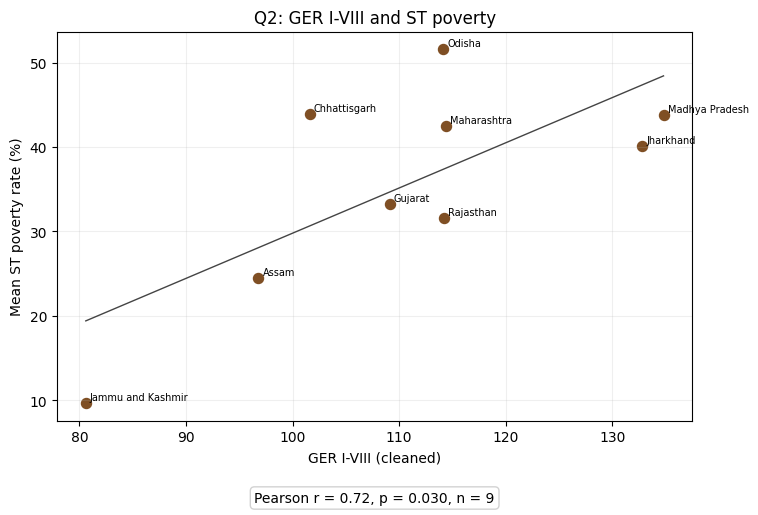

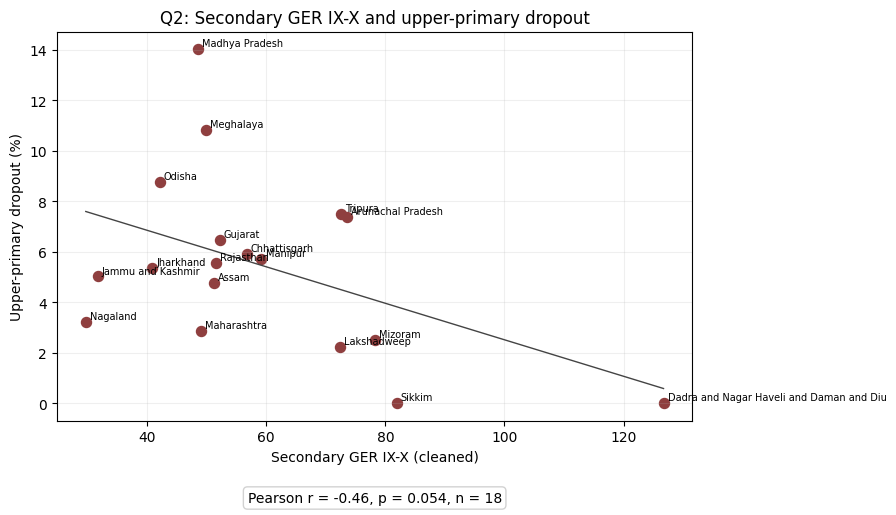

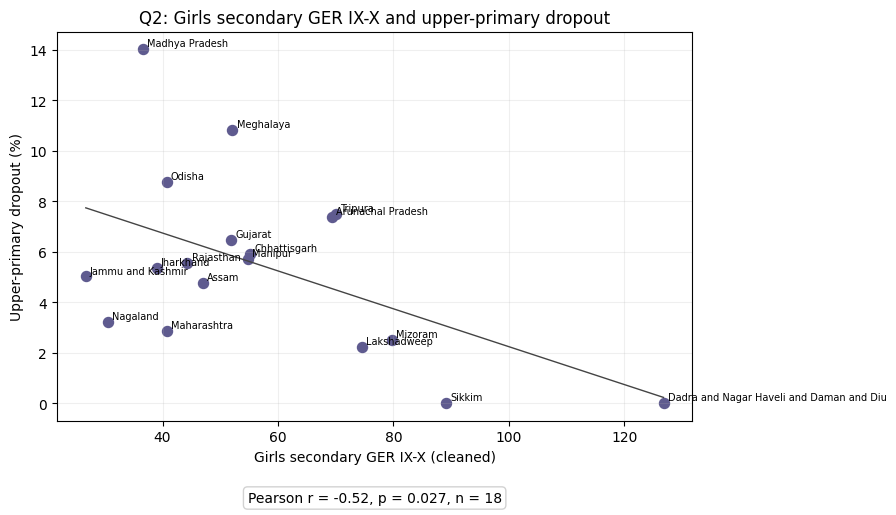

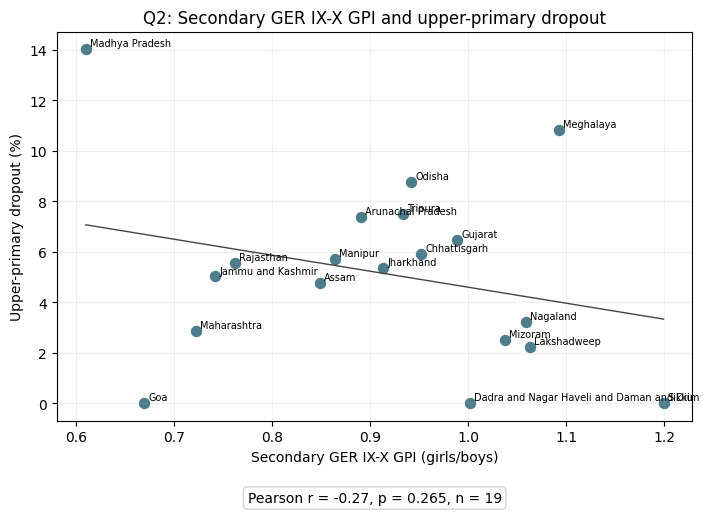

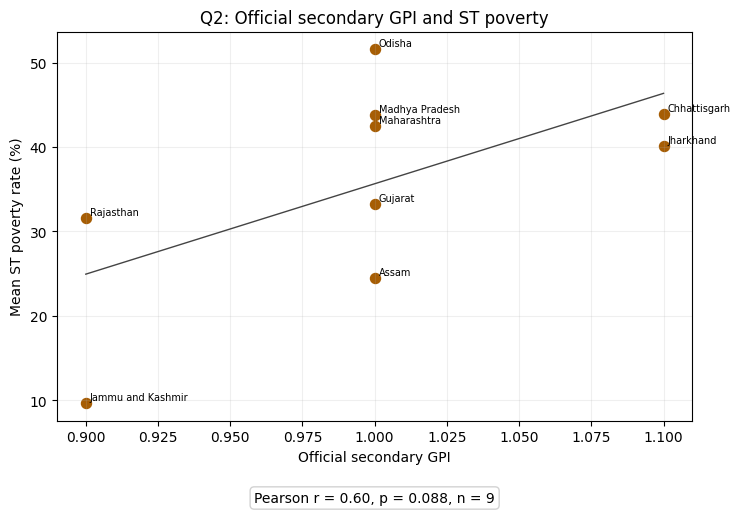

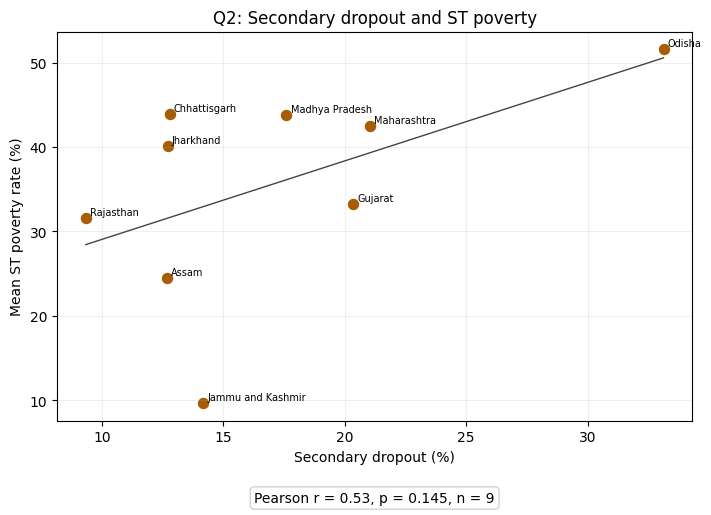

In [12]:
show_scatter(high_st, "ger_classes_i_viii_clean", "st_bpl_mean_pct", "Q2: GER I-VIII and ST poverty", "GER I-VIII (cleaned)", "Mean ST poverty rate (%)", color="#7f4f24")
show_scatter(high_st, "ger_classes_ix_x_clean", "dropout_upper_primary_pct", "Q2: Secondary GER IX-X and upper-primary dropout", "Secondary GER IX-X (cleaned)", "Upper-primary dropout (%)", color="#8f3f3f")
show_scatter(high_st, "ger_classes_ix_x_girls_clean", "dropout_upper_primary_pct", "Q2: Girls secondary GER IX-X and upper-primary dropout", "Girls secondary GER IX-X (cleaned)", "Upper-primary dropout (%)", color="#5f5b8f")
show_scatter(high_st, "ger_classes_ix_x_gpi_clean", "dropout_upper_primary_pct", "Q2: Secondary GER IX-X GPI and upper-primary dropout", "Secondary GER IX-X GPI (girls/boys)", "Upper-primary dropout (%)", color="#4d7c8a")
show_scatter(high_st, "gpi_secondary_clean", "st_bpl_mean_pct", "Q2: Official secondary GPI and ST poverty", "Official secondary GPI", "Mean ST poverty rate (%)", color="#a65d03")
show_scatter(high_st, "dropout_secondary_pct", "st_bpl_mean_pct", "Q2: Secondary dropout and ST poverty", "Secondary dropout (%)", "Mean ST poverty rate (%)", color="#a65d03")

In [13]:
high_dropout_high_poverty = high_st[
    high_st["dropout_secondary_pct"].notna() & high_st["st_bpl_mean_pct"].notna()
][[
    "state",
    "ger_classes_i_viii_clean",
    "ger_classes_ix_x_clean",
    "ger_latest_secondary_total_clean",
    "ger_classes_ix_x_girls_clean",
    "ger_latest_secondary_girls_clean",
    "gpi_secondary_clean",
    "ger_classes_ix_x_gpi_clean",
    "dropout_upper_primary_pct",
    "dropout_secondary_pct",
    "st_bpl_mean_pct",
    "employment_wpr_person_per_1000",
    "mgnreg_sought_not_received_per_1000",
]].sort_values(["dropout_secondary_pct", "st_bpl_mean_pct"], ascending=[False, False])

high_dropout_high_poverty

,state,ger_classes_i_viii_clean,ger_classes_ix_x_clean,ger_latest_secondary_total_clean,ger_classes_ix_x_girls_clean,ger_latest_secondary_girls_clean,gpi_secondary_clean,ger_classes_ix_x_gpi_clean,dropout_upper_primary_pct,dropout_secondary_pct,st_bpl_mean_pct,employment_wpr_person_per_1000,mgnreg_sought_not_received_per_1000
0,Odisha,114.1,42.1,87.1,40.7,89.6,1.0,0.942130,8.77,33.12,51.60,504.0,255
3,Maharashtra,114.4,49.0,91.1,40.8,91.5,1.0,0.722124,2.85,21.04,42.45,501.0,218
8,Gujarat,109.1,52.2,76.4,51.9,75.9,1.0,0.988571,6.47,20.35,33.30,465.0,96
1,Madhya Pradesh,134.8,48.5,56.2,36.6,56.3,1.0,0.610000,14.02,17.60,43.80,452.0,236
7,Jammu and Kashmir,80.6,31.7,64.0,26.7,62.3,0.9,0.741667,5.02,14.17,9.65,620.0,32
6,Chhattisgarh,101.6,56.7,67.8,55.2,72.4,1.1,0.951724,5.92,12.79,43.90,455.0,233
2,Jharkhand,132.8,40.9,57.7,39.0,60.2,1.1,0.913349,5.37,12.71,40.15,375.0,245
11,Assam,96.8,51.2,94.7,47.0,96.8,1.0,0.848375,4.76,12.67,24.50,386.0,282
4,Rajasthan,114.2,51.5,79.8,44.3,79.4,0.9,0.762478,5.57,9.34,31.55,454.0,82


**Reading Q2:** this is stronger than using literacy alone. For stage interpretation, use the correct levels: primary is I-V, upper primary is VI-VIII, secondary is IX-X, and senior secondary is XI-XII. The available historical GER file does not provide a pure VI-VIII GER, so transition analysis uses IX-X GER against upper-primary dropout. GER I-VIII is used only as a broad early-schooling participation measure, not as a pure primary or upper-primary measure. If GER is high but dropout or poverty is also high, schooling access is not translating into stable progression or economic security.

## Q3. Are Enrolment And GER Enough To Indicate Educational Progress, Or Do Dropout Rates Tell A Different Story?

In [14]:
q3 = corr_frame(
    high_st,
    [
        "ger_classes_i_viii_clean",
        "ger_classes_ix_x_clean",
        "ger_classes_ix_x_girls_clean",
        "ger_classes_xi_xii_clean",
        "ger_latest_secondary_total_clean",
        "ger_latest_higher_secondary_total_clean",
        "gpi_secondary_clean",
    ],
    ["dropout_upper_primary_pct", "dropout_secondary_pct", "employment_wpr_person_per_1000", "st_bpl_mean_pct"],
    "high_st_states",
)
q3

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,ger_classes_i_viii_clean,st_bpl_mean_pct,9,0.7172,0.0296,0.7172
1,high_st_states,gpi_secondary_clean,st_bpl_mean_pct,9,0.5993,0.0881,0.5993
2,high_st_states,ger_classes_ix_x_girls_clean,dropout_upper_primary_pct,18,-0.5197,0.0271,0.5197
3,high_st_states,ger_classes_xi_xii_clean,dropout_upper_primary_pct,18,-0.5131,0.0294,0.5131
4,high_st_states,ger_classes_ix_x_clean,dropout_upper_primary_pct,18,-0.4621,0.0535,0.4621
5,high_st_states,ger_latest_secondary_total_clean,dropout_secondary_pct,19,0.4549,0.0504,0.4549
6,high_st_states,ger_classes_ix_x_clean,st_bpl_mean_pct,9,0.4178,0.2631,0.4178
7,high_st_states,ger_classes_xi_xii_clean,dropout_secondary_pct,18,-0.3989,0.1010,0.3989
8,high_st_states,ger_classes_ix_x_clean,dropout_secondary_pct,18,-0.3889,0.1107,0.3889
9,high_st_states,ger_classes_ix_x_girls_clean,st_bpl_mean_pct,9,0.3868,0.3038,0.3868


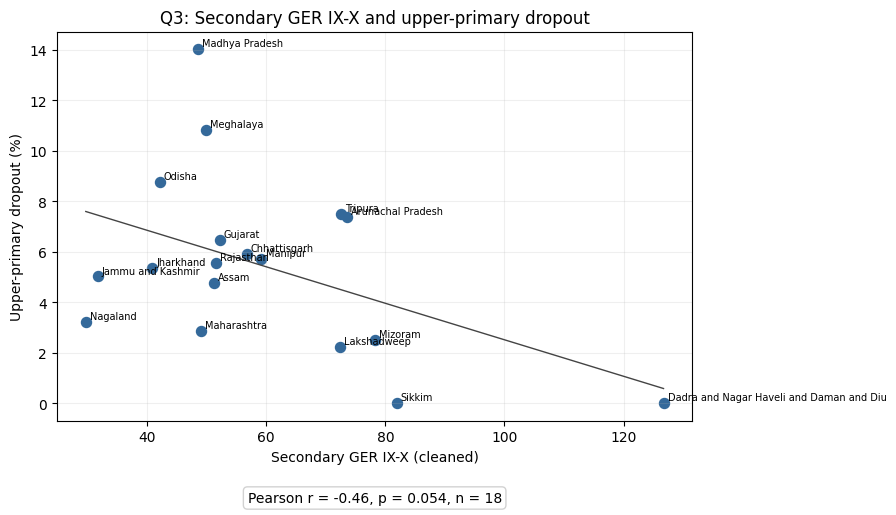

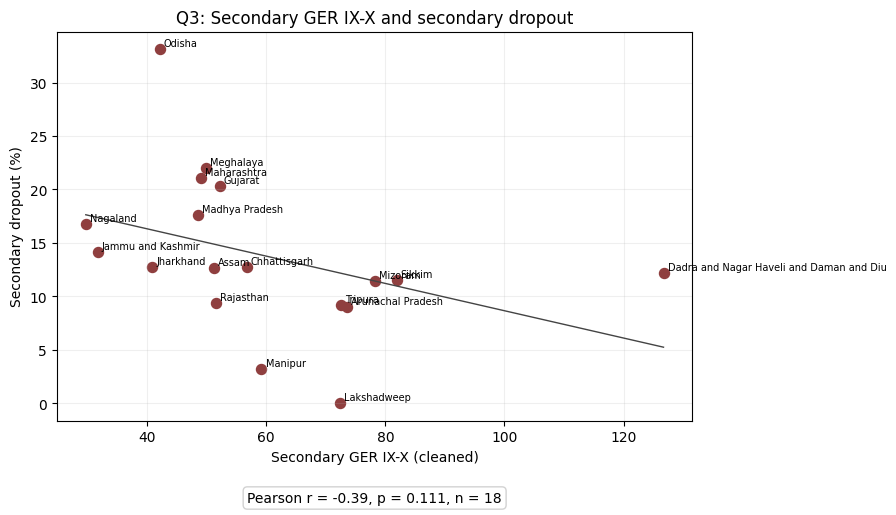

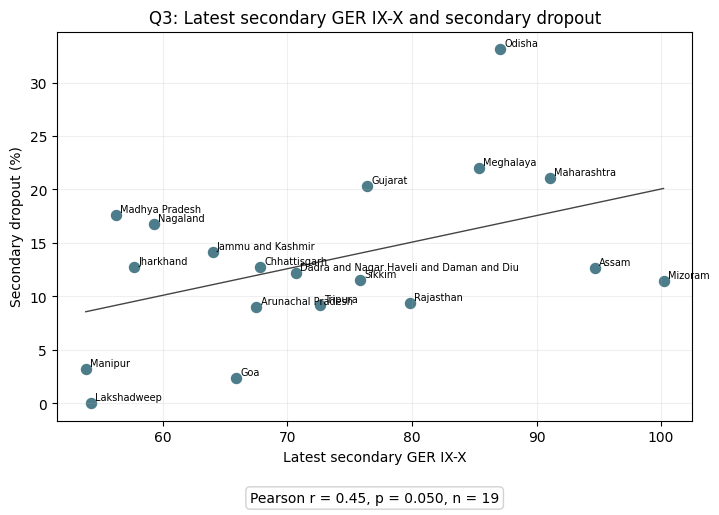

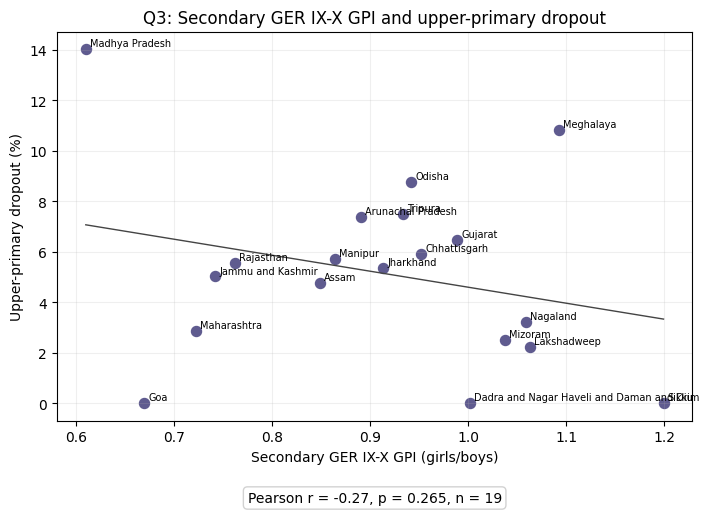

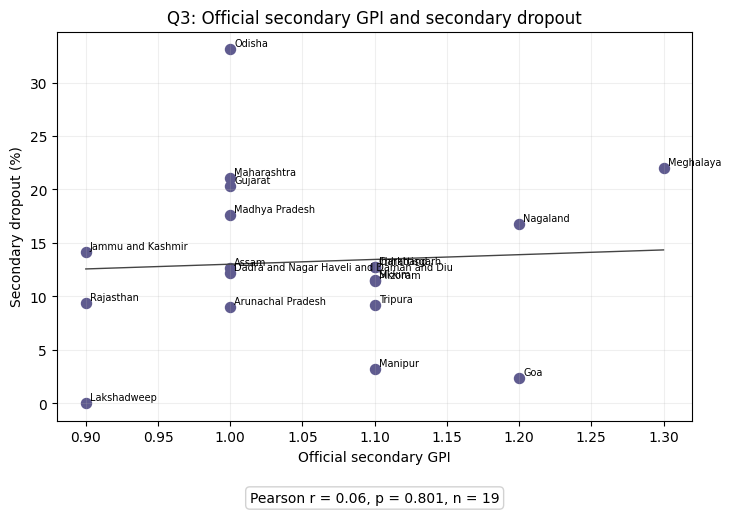

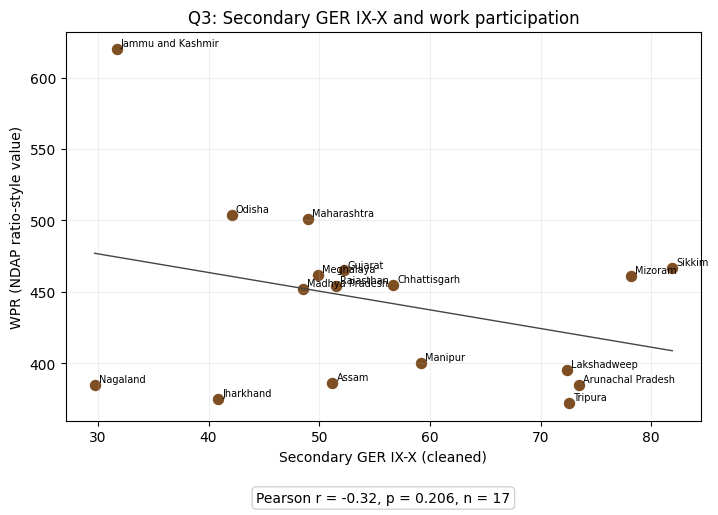

In [15]:
show_scatter(high_st, "ger_classes_ix_x_clean", "dropout_upper_primary_pct", "Q3: Secondary GER IX-X and upper-primary dropout", "Secondary GER IX-X (cleaned)", "Upper-primary dropout (%)")
show_scatter(high_st, "ger_classes_ix_x_clean", "dropout_secondary_pct", "Q3: Secondary GER IX-X and secondary dropout", "Secondary GER IX-X (cleaned)", "Secondary dropout (%)", color="#8f3f3f")
show_scatter(high_st, "ger_latest_secondary_total_clean", "dropout_secondary_pct", "Q3: Latest secondary GER IX-X and secondary dropout", "Latest secondary GER IX-X", "Secondary dropout (%)", color="#4d7c8a")
show_scatter(high_st, "ger_classes_ix_x_gpi_clean", "dropout_upper_primary_pct", "Q3: Secondary GER IX-X GPI and upper-primary dropout", "Secondary GER IX-X GPI (girls/boys)", "Upper-primary dropout (%)", color="#5f5b8f")
show_scatter(high_st, "gpi_secondary_clean", "dropout_secondary_pct", "Q3: Official secondary GPI and secondary dropout", "Official secondary GPI", "Secondary dropout (%)", color="#5f5b8f")
show_scatter(high_st, "ger_classes_ix_x_clean", "employment_wpr_person_per_1000", "Q3: Secondary GER IX-X and work participation", "Secondary GER IX-X (cleaned)", "WPR (NDAP ratio-style value)", color="#7f4f24")

In [16]:
med_ger = high_st["ger_latest_secondary_total_clean"].median()
med_dropout = high_st["dropout_secondary_pct"].median()
med_wpr = high_st["employment_wpr_person_per_1000"].median()

high_ger_high_dropout = high_st[
    (high_st["ger_latest_secondary_total_clean"] >= med_ger)
    & (high_st["dropout_secondary_pct"] >= med_dropout)
][["state", "ger_latest_secondary_total_clean", "gpi_secondary_clean", "dropout_upper_primary_pct", "dropout_secondary_pct", "employment_wpr_person_per_1000", "st_bpl_mean_pct"]].sort_values(["dropout_secondary_pct", "ger_latest_secondary_total_clean"], ascending=[False, False])

high_ger_low_wpr = high_st[
    (high_st["ger_latest_secondary_total_clean"] >= med_ger)
    & (high_st["employment_wpr_person_per_1000"] <= med_wpr)
][["state", "ger_latest_secondary_total_clean", "gpi_secondary_clean", "dropout_upper_primary_pct", "dropout_secondary_pct", "employment_wpr_person_per_1000", "st_bpl_mean_pct"]].sort_values("employment_wpr_person_per_1000")

display(Markdown("### States with relatively high latest secondary GER IX-X but also high dropout"))
display(high_ger_high_dropout)
display(Markdown("### States with relatively high latest secondary GER IX-X but weak work participation"))
display(high_ger_low_wpr)

### States with relatively high latest secondary GER IX-X but also high dropout

,state,ger_latest_secondary_total_clean,gpi_secondary_clean,dropout_upper_primary_pct,dropout_secondary_pct,employment_wpr_person_per_1000,st_bpl_mean_pct
0,Odisha,87.1,1.0,8.77,33.12,504.0,51.60
14,Meghalaya,85.4,1.3,10.83,21.99,462.0,NaN
3,Maharashtra,91.1,1.0,2.85,21.04,501.0,42.45
8,Gujarat,76.4,1.0,6.47,20.35,465.0,33.30
11,Assam,94.7,1.0,4.76,12.67,386.0,24.50


### States with relatively high latest secondary GER IX-X but weak work participation

,state,ger_latest_secondary_total_clean,gpi_secondary_clean,dropout_upper_primary_pct,dropout_secondary_pct,employment_wpr_person_per_1000,st_bpl_mean_pct
9,Tripura,72.6,1.1,7.49,9.21,372.0,NaN
11,Assam,94.7,1.0,4.76,12.67,386.0,24.5


**Reading Q3:** access-style indicators are not enough. Some states show reasonable GER but still struggle with retention or weak work participation.

## Q4. Is The Literacy Gap More Informative Than ST Literacy Alone In Explaining Disadvantage?

In [17]:
q4 = compare_predictors(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "dropout_secondary_pct"],
)
q4

,outcome,stronger_predictor,n,pearson_r,pearson_p,runner_up,runner_up_abs_r
0,st_bpl_mean_pct,literacy_gap_pct,9,0.3275,0.3896,st_literacy_rate_pct,0.0652
1,employment_wpr_person_per_1000,literacy_gap_pct,18,0.5387,0.0211,st_literacy_rate_pct,0.4766
2,employment_pu_person_per_1000,st_literacy_rate_pct,18,0.6177,0.0063,literacy_gap_pct,0.4900
3,dropout_secondary_pct,literacy_gap_pct,18,0.5099,0.0306,st_literacy_rate_pct,0.5051


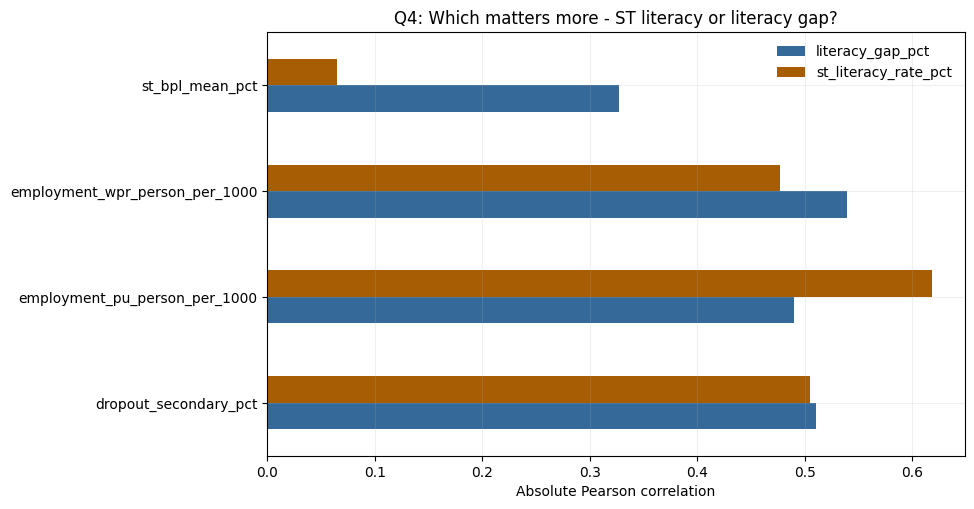

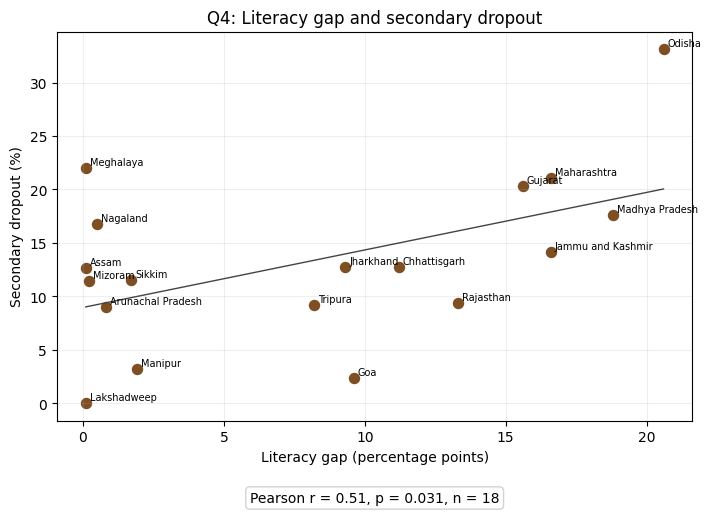

In [18]:
show_abs_correlation_compare(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "dropout_secondary_pct"],
    "Q4: Which matters more - ST literacy or literacy gap?",
)
show_scatter(high_st, "literacy_gap_pct", "dropout_secondary_pct", "Q4: Literacy gap and secondary dropout", "Literacy gap (percentage points)", "Secondary dropout (%)", color="#7f4f24")

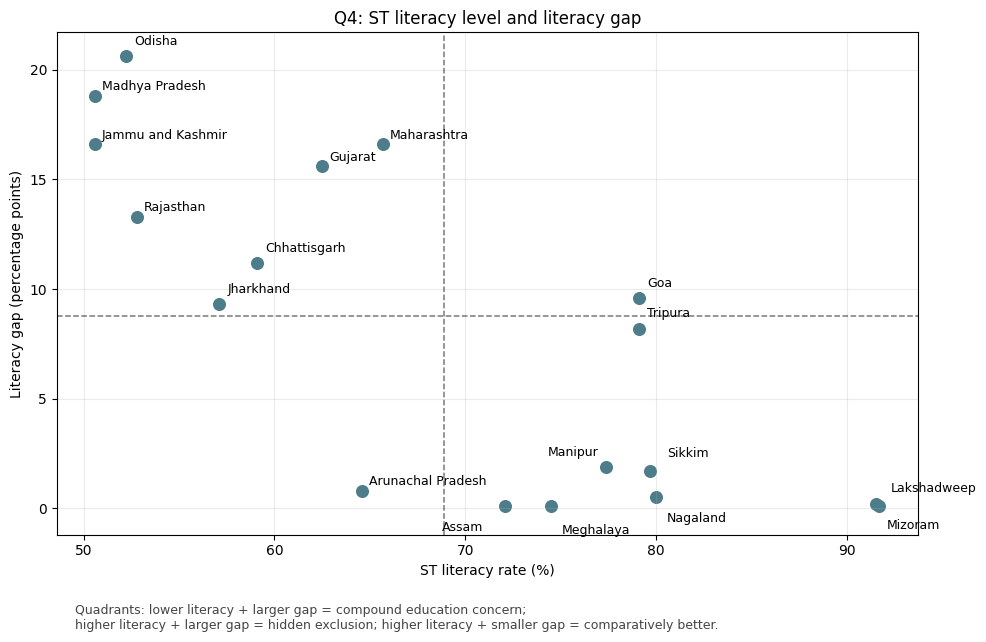

In [19]:
literacy_quadrants = high_st[["state", "st_literacy_rate_pct", "literacy_gap_pct"]].dropna().copy()
x_med = literacy_quadrants["st_literacy_rate_pct"].median()
y_med = literacy_quadrants["literacy_gap_pct"].median()

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(literacy_quadrants["st_literacy_rate_pct"], literacy_quadrants["literacy_gap_pct"], color="#4d7c8a", s=70)
ax.axvline(x_med, color="#333333", linestyle="--", linewidth=1.1, alpha=0.65)
ax.axhline(y_med, color="#333333", linestyle="--", linewidth=1.1, alpha=0.65)
label_offsets = {
    "Assam": (-46, -18),
    "Meghalaya": (8, -20),
    "Manipur": (-42, 8),
    "Sikkim": (12, 10),
    "Nagaland": (8, -18),
    "Lakshadweep": (8, 10),
    "Mizoram": (8, -18),
    "Tripura": (6, 8),
    "Goa": (6, 8),
    "Jharkhand": (6, 8),
    "Chhattisgarh": (6, 8),
    "Odisha": (6, 8),
}
for _, row in literacy_quadrants.iterrows():
    offset = label_offsets.get(row["state"], (5, 4))
    ax.annotate(row["state"], (row["st_literacy_rate_pct"], row["literacy_gap_pct"]), xytext=offset, textcoords="offset points", fontsize=9)
ax.set_xlim(literacy_quadrants["st_literacy_rate_pct"].min() - 2, literacy_quadrants["st_literacy_rate_pct"].max() + 2)
ax.set_ylim(literacy_quadrants["literacy_gap_pct"].min() - 1.3, literacy_quadrants["literacy_gap_pct"].max() + 1.1)
ax.set_title("Q4: ST literacy level and literacy gap")
ax.set_xlabel("ST literacy rate (%)")
ax.set_ylabel("Literacy gap (percentage points)")
ax.grid(True, alpha=0.25)
caption = (
    "Quadrants: lower literacy + larger gap = compound education concern;\n"
    "higher literacy + larger gap = hidden exclusion; higher literacy + smaller gap = comparatively better."
)
fig.text(
    0.08,
    0.02,
    caption,
    ha="left",
    va="bottom",
    fontsize=9,
    color="#444444",
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

**Reading Q4:** the literacy gap is useful because it captures exclusion relative to the rest of the state, not just low ST literacy. The cleanest added evidence is the positive relationship between literacy gap and secondary dropout. The quadrant chart helps separate states with generally low ST literacy from states where ST literacy may look less severe but the gap remains large.

## Q5. Are There States Where Educational Indicators Look Reasonable, But Employment Or Poverty Outcomes Remain Weak?

We label these as **states with an education-livelihood mismatch**.

In [20]:
med_lit = high_st["st_literacy_rate_pct"].median()
med_ger = high_st["ger_latest_secondary_total_clean"].median()
med_wpr = high_st["employment_wpr_person_per_1000"].median()
med_unemp = high_st["employment_pu_person_per_1000"].median()
med_pov = high_st["st_bpl_mean_pct"].median()
med_mgnreg = high_st["mgnreg_sought_not_received_per_1000"].median()
med_mgnreg_100 = high_st["mgnreg_work_100_plus_days_per_1000"].median()

mismatch_rows = []
for _, row in high_st.iterrows():
    education_ok = (
        (pd.notna(row["st_literacy_rate_pct"]) and row["st_literacy_rate_pct"] >= med_lit)
        or (pd.notna(row["ger_latest_secondary_total_clean"]) and row["ger_latest_secondary_total_clean"] >= med_ger)
    )
    distress = []
    if pd.notna(row["employment_wpr_person_per_1000"]) and row["employment_wpr_person_per_1000"] <= med_wpr:
        distress.append("low_wpr")
    if pd.notna(row["employment_pu_person_per_1000"]) and row["employment_pu_person_per_1000"] >= med_unemp:
        distress.append("high_unemployment")
    if pd.notna(row["st_bpl_mean_pct"]) and row["st_bpl_mean_pct"] >= med_pov:
        distress.append("high_poverty")
    if pd.notna(row["mgnreg_sought_not_received_per_1000"]) and row["mgnreg_sought_not_received_per_1000"] >= med_mgnreg:
        distress.append("high_mgnreg_unmet")
    if pd.notna(row["mgnreg_work_100_plus_days_per_1000"]) and row["mgnreg_work_100_plus_days_per_1000"] >= med_mgnreg_100:
        distress.append("high_mgnreg_100_plus")

    if education_ok and len(distress) >= 2:
        mismatch_rows.append(
            {
                "state": row["state"],
                "st_literacy_rate_pct": row["st_literacy_rate_pct"],
                "ger_secondary_ix_x": row["ger_classes_ix_x_clean"],
                "ger_latest_secondary": row["ger_latest_secondary_total_clean"],
                "employment_wpr_person_per_1000": row["employment_wpr_person_per_1000"],
                "employment_pu_person_per_1000": row["employment_pu_person_per_1000"],
                "st_bpl_mean_pct": row["st_bpl_mean_pct"],
                "mgnreg_sought_not_received_per_1000": row["mgnreg_sought_not_received_per_1000"],
                "mgnreg_work_100_plus_days_per_1000": row["mgnreg_work_100_plus_days_per_1000"],
                "distress_count": len(distress),
                "distress_flags": ", ".join(distress),
            }
        )

mismatch_df = pd.DataFrame(mismatch_rows).sort_values(["distress_count", "state"], ascending=[False, True])
mismatch_df

,state,st_literacy_rate_pct,ger_secondary_ix_x,ger_latest_secondary,employment_wpr_person_per_1000,employment_pu_person_per_1000,st_bpl_mean_pct,mgnreg_sought_not_received_per_1000,mgnreg_work_100_plus_days_per_1000,distress_count,distress_flags
5,Assam,72.1,51.2,94.7,386.0,18.0,24.50,282,2,4,"low_wpr, high_unemployment, high_mgnreg_unmet, high_mgnreg_100_plus"
2,Nagaland,80.0,29.7,59.3,385.0,47.0,NaN,154,0,4,"low_wpr, high_unemployment, high_mgnreg_unmet, high_mgnreg_100_plus"
8,Goa,79.1,NaN,65.9,362.0,15.0,NaN,6,0,3,"low_wpr, high_unemployment, high_mgnreg_100_plus"
9,Lakshadweep,91.7,72.4,54.2,395.0,38.0,NaN,21,0,3,"low_wpr, high_unemployment, high_mgnreg_100_plus"
1,Maharashtra,65.7,49.0,91.1,501.0,4.0,42.45,218,0,3,"high_poverty, high_mgnreg_unmet, high_mgnreg_100_plus"
10,Manipur,77.4,59.2,53.8,400.0,10.0,NaN,9,0,3,"low_wpr, high_unemployment, high_mgnreg_100_plus"
0,Odisha,52.2,42.1,87.1,504.0,7.0,51.60,255,0,3,"high_poverty, high_mgnreg_unmet, high_mgnreg_100_plus"
3,Tripura,79.1,72.6,72.6,372.0,38.0,NaN,39,0,3,"low_wpr, high_unemployment, high_mgnreg_100_plus"
4,Dadra and Nagar Haveli and Daman and Diu,NaN,126.7,70.7,NaN,NaN,NaN,220,0,2,"high_mgnreg_unmet, high_mgnreg_100_plus"
7,Meghalaya,74.5,49.9,85.4,462.0,5.0,NaN,141,0,2,"high_mgnreg_unmet, high_mgnreg_100_plus"


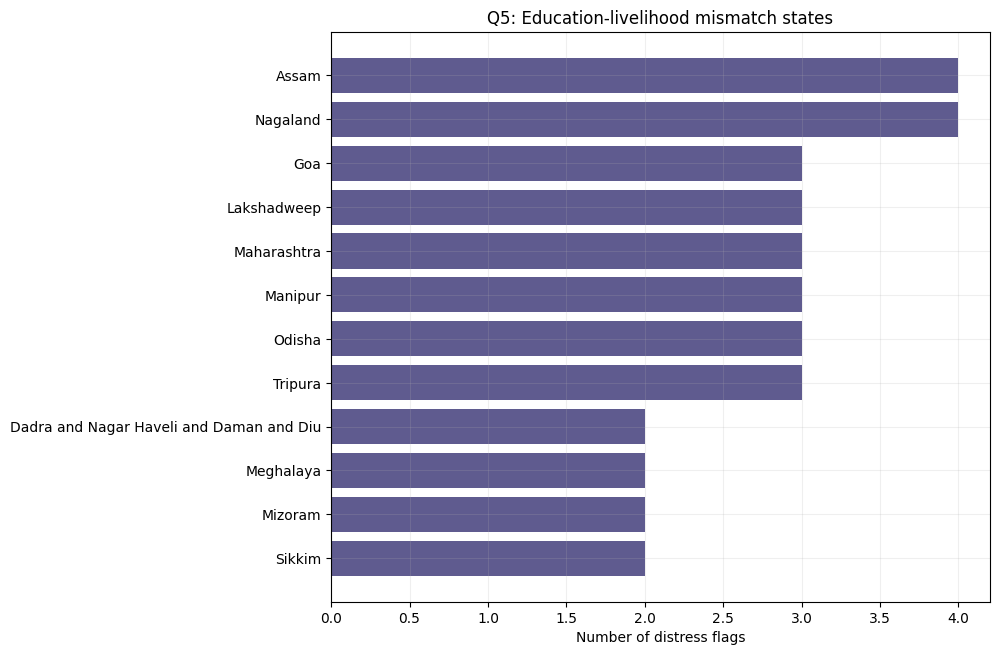

In [21]:
if not mismatch_df.empty:
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(mismatch_df) + 2))
    ax.barh(mismatch_df["state"], mismatch_df["distress_count"], color="#5f5b8f")
    ax.invert_yaxis()
    ax.set_title("Q5: Education-livelihood mismatch states")
    ax.set_xlabel("Number of distress flags")
    plt.show()

**Reading Q5:** this is one of the most policy-useful outputs. These states do not fit a simple low-education-equals-bad-outcomes story.

## Q6. Does MGNREG Unmet Demand Reflect Deeper Livelihood Distress Among ST Households?

In [22]:
q6 = corr_pairs(
    high_st,
    [
        ("mgnreg_sought_not_received_per_1000", "st_bpl_mean_pct"),
        ("mgnreg_sought_not_received_per_1000", "dropout_secondary_pct"),
        ("mgnreg_sought_not_received_per_1000", "st_literacy_rate_pct"),
        ("mgnreg_work_100_plus_days_per_1000", "dropout_secondary_pct"),
    ],
    "high_st_states",
)
q6

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,mgnreg_sought_not_received_per_1000,st_bpl_mean_pct,9,0.6488,0.0587,0.6488
1,high_st_states,mgnreg_sought_not_received_per_1000,st_literacy_rate_pct,18,-0.5271,0.0246,0.5271
2,high_st_states,mgnreg_sought_not_received_per_1000,dropout_secondary_pct,19,0.5114,0.0252,0.5114
3,high_st_states,mgnreg_work_100_plus_days_per_1000,dropout_secondary_pct,19,-0.0462,0.8511,0.0462


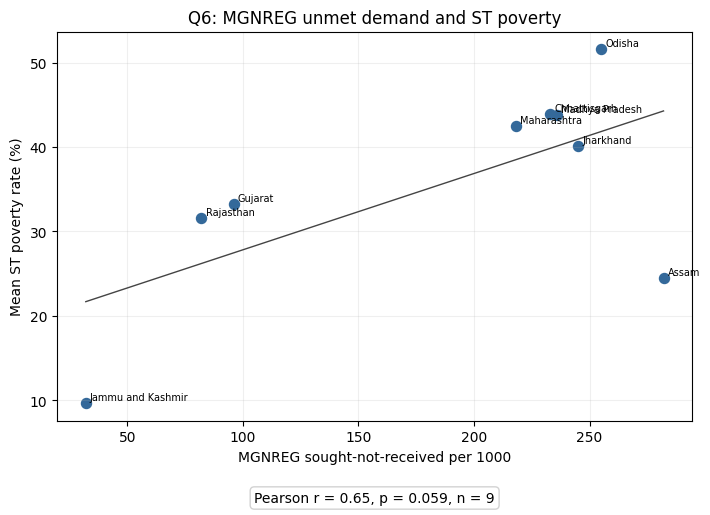

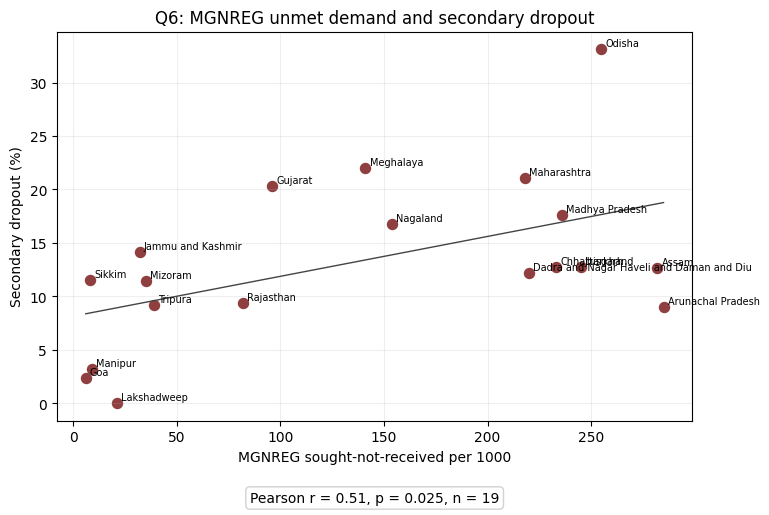

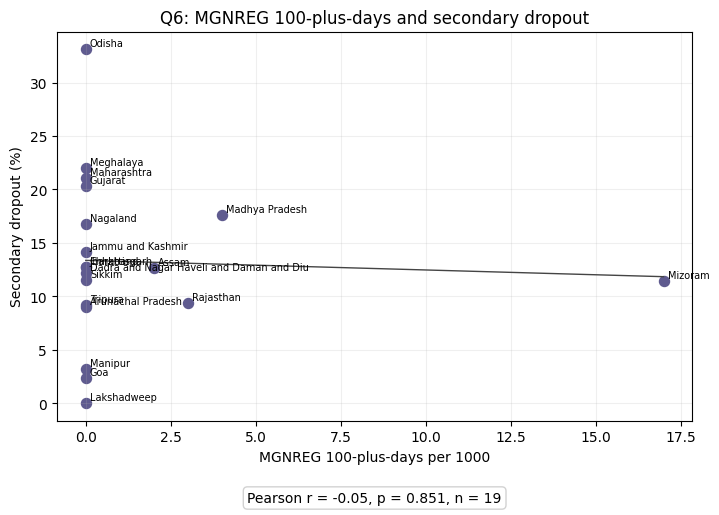

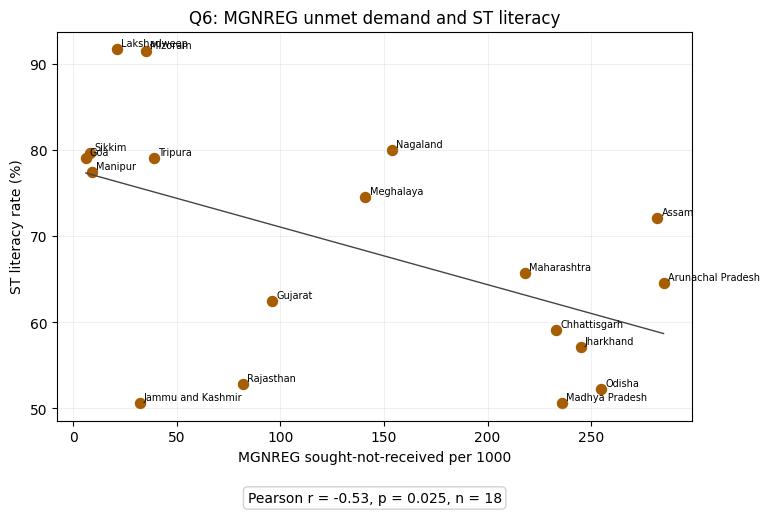

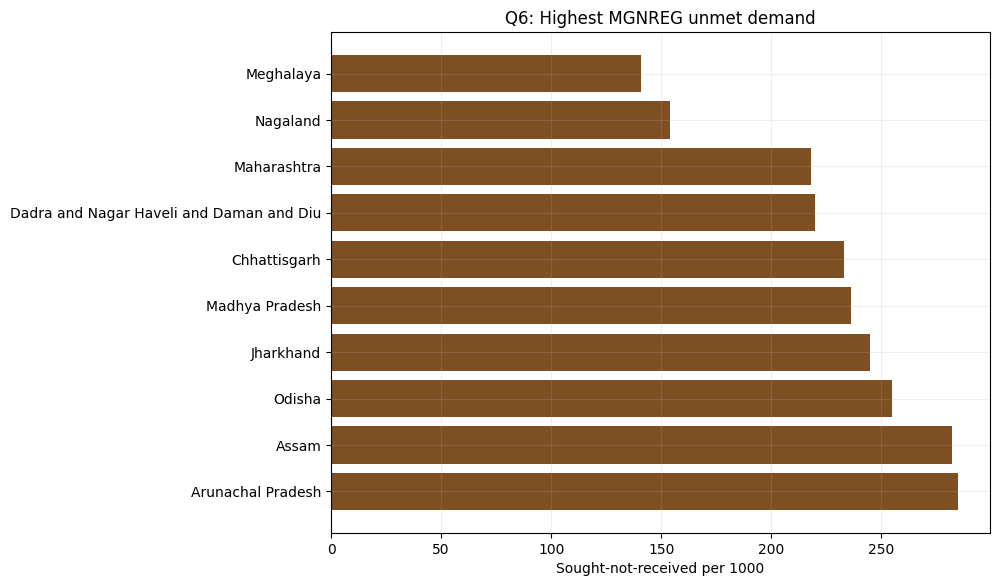

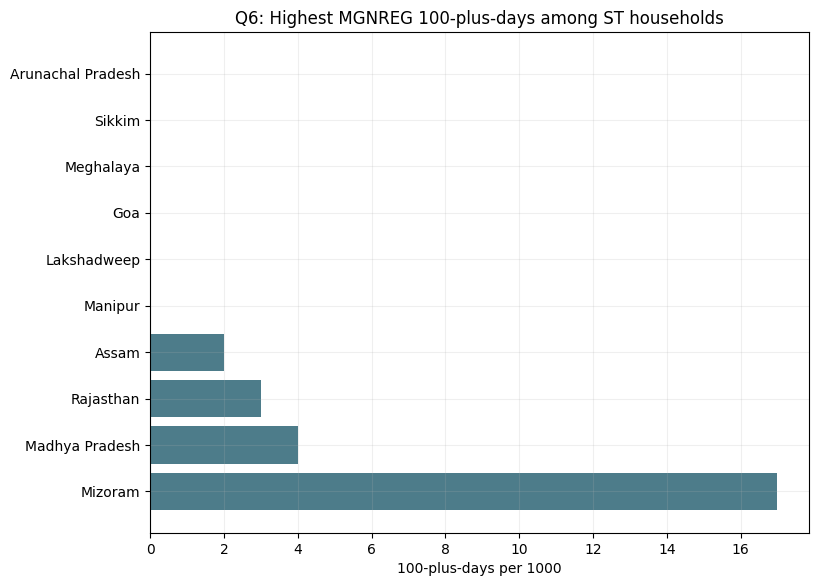

In [23]:
show_scatter(high_st, "mgnreg_sought_not_received_per_1000", "st_bpl_mean_pct", "Q6: MGNREG unmet demand and ST poverty", "MGNREG sought-not-received per 1000", "Mean ST poverty rate (%)")
show_scatter(high_st, "mgnreg_sought_not_received_per_1000", "dropout_secondary_pct", "Q6: MGNREG unmet demand and secondary dropout", "MGNREG sought-not-received per 1000", "Secondary dropout (%)", color="#8f3f3f")
show_scatter(high_st, "mgnreg_work_100_plus_days_per_1000", "dropout_secondary_pct", "Q6: MGNREG 100-plus-days and secondary dropout", "MGNREG 100-plus-days per 1000", "Secondary dropout (%)", color="#5f5b8f")
show_scatter(high_st, "mgnreg_sought_not_received_per_1000", "st_literacy_rate_pct", "Q6: MGNREG unmet demand and ST literacy", "MGNREG sought-not-received per 1000", "ST literacy rate (%)", color="#a65d03")
show_rank_bar(high_st, "mgnreg_sought_not_received_per_1000", "Q6: Highest MGNREG unmet demand", "Sought-not-received per 1000", ascending=False, top_n=10, color="#7f4f24")
show_rank_bar(high_st, "mgnreg_work_100_plus_days_per_1000", "Q6: Highest MGNREG 100-plus-days among ST households", "100-plus-days per 1000", ascending=False, top_n=10, color="#4d7c8a")

**Reading Q6:** unmet MGNREG demand is the useful MGNREG distress signal here. It is positively associated with ST poverty and secondary dropout, and negatively associated with ST literacy. The 100-plus-days measure is much weaker against dropout, so it should be treated as context rather than the main finding.

## Q7. Are Scholarship-Supported States Seeing Lower Secondary Dropout Among ST Students?

This is a policy-response question. The scholarship dataset measures pre-matric and post-matric ST scholarship release and utilization in Rs lakh. Because larger states naturally receive larger totals, the notebook also uses release per 100,000 ST population.

In [24]:
q7 = corr_frame(
    high_st,
    [
        "scholarship_total_release_2023_24_lakh",
        "scholarship_total_utilized_2023_24_lakh",
        "scholarship_utilization_2023_24_pct",
        "scholarship_total_release_2023_24_lakh_per_100k_st_pop",
        "scholarship_cumulative_release_lakh_per_100k_st_pop",
    ],
    ["dropout_secondary_pct", "st_bpl_mean_pct", "ger_latest_secondary_total_clean"],
    "high_st_states",
)
q7

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,scholarship_total_release_2023_24_lakh,dropout_secondary_pct,18,0.4494,0.0614,0.4494
1,high_st_states,scholarship_total_utilized_2023_24_lakh,st_bpl_mean_pct,9,0.4246,0.2546,0.4246
2,high_st_states,scholarship_total_release_2023_24_lakh,st_bpl_mean_pct,9,0.4162,0.2652,0.4162
3,high_st_states,scholarship_total_utilized_2023_24_lakh,dropout_secondary_pct,18,0.4091,0.0918,0.4091
4,high_st_states,scholarship_cumulative_release_lakh_per_100k_st_pop,st_bpl_mean_pct,9,0.3748,0.3202,0.3748
5,high_st_states,scholarship_cumulative_release_lakh_per_100k_st_pop,dropout_secondary_pct,18,-0.3663,0.1349,0.3663
6,high_st_states,scholarship_total_release_2023_24_lakh_per_100k_st_pop,st_bpl_mean_pct,9,0.3094,0.4179,0.3094
7,high_st_states,scholarship_total_utilized_2023_24_lakh,ger_latest_secondary_total_clean,18,0.1882,0.4545,0.1882
8,high_st_states,scholarship_utilization_2023_24_pct,st_bpl_mean_pct,9,-0.1820,0.6393,0.1820
9,high_st_states,scholarship_total_release_2023_24_lakh,ger_latest_secondary_total_clean,18,0.1693,0.5019,0.1693


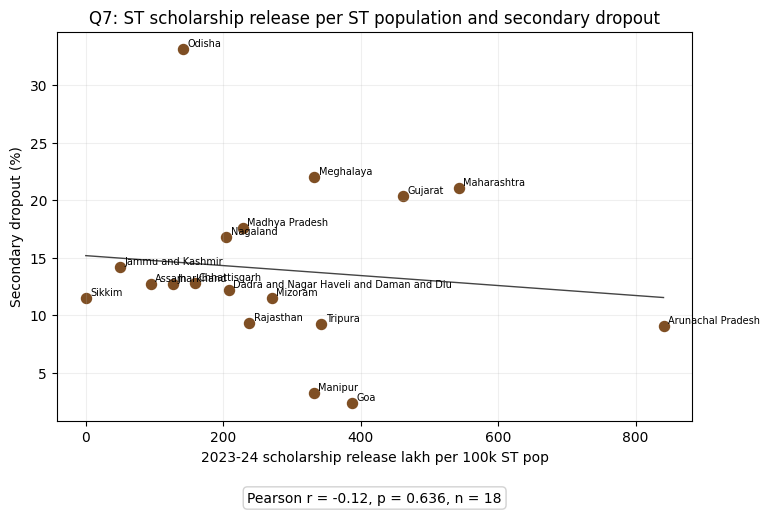

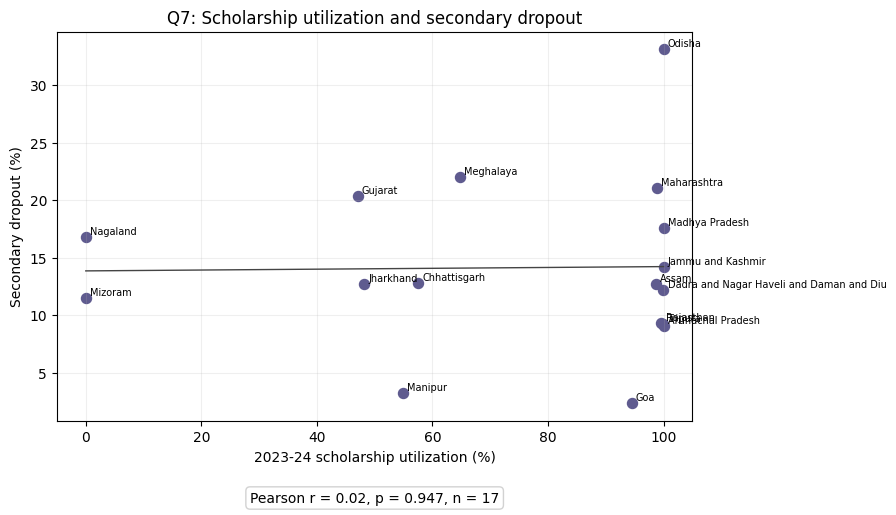

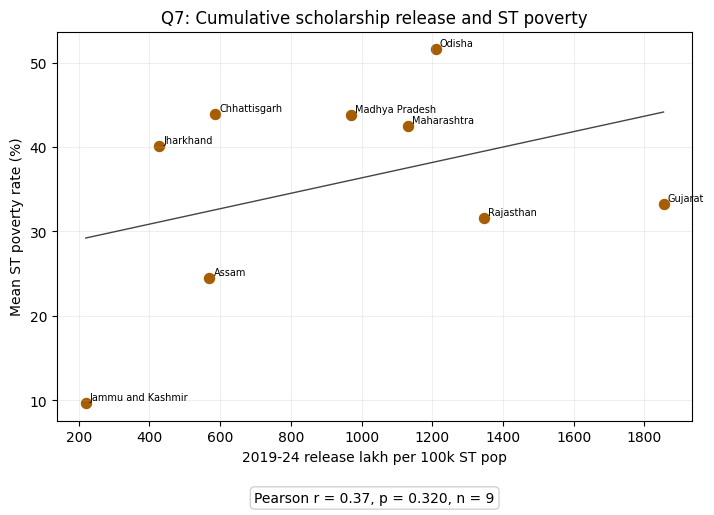

In [25]:
show_scatter(high_st, "scholarship_total_release_2023_24_lakh_per_100k_st_pop", "dropout_secondary_pct", "Q7: ST scholarship release per ST population and secondary dropout", "2023-24 scholarship release lakh per 100k ST pop", "Secondary dropout (%)", color="#7f4f24")
show_scatter(high_st, "scholarship_utilization_2023_24_pct", "dropout_secondary_pct", "Q7: Scholarship utilization and secondary dropout", "2023-24 scholarship utilization (%)", "Secondary dropout (%)", color="#5f5b8f")
show_scatter(high_st, "scholarship_cumulative_release_lakh_per_100k_st_pop", "st_bpl_mean_pct", "Q7: Cumulative scholarship release and ST poverty", "2019-24 release lakh per 100k ST pop", "Mean ST poverty rate (%)", color="#a65d03")

In [26]:
high_st[[
    "state",
    "dropout_secondary_pct",
    "st_bpl_mean_pct",
    "scholarship_total_release_2023_24_lakh",
    "scholarship_total_utilized_2023_24_lakh",
    "scholarship_utilization_2023_24_pct",
    "scholarship_total_release_2023_24_lakh_per_100k_st_pop",
    "scholarship_cumulative_release_lakh_per_100k_st_pop",
]].sort_values("scholarship_total_release_2023_24_lakh_per_100k_st_pop", ascending=False)

,state,dropout_secondary_pct,st_bpl_mean_pct,scholarship_total_release_2023_24_lakh,scholarship_total_utilized_2023_24_lakh,scholarship_utilization_2023_24_pct,scholarship_total_release_2023_24_lakh_per_100k_st_pop,scholarship_cumulative_release_lakh_per_100k_st_pop
12,Arunachal Pradesh,9.04,NaN,8000.00,8000.00,100.000000,840.494169,4441.812063
3,Maharashtra,21.04,42.45,57035.80,56371.80,98.835819,542.670258,1132.254598
8,Gujarat,20.35,33.30,41200.00,19400.00,47.087379,462.029787,1854.475196
15,Goa,2.34,NaN,579.04,546.97,94.461523,387.901524,2135.206833
9,Tripura,9.21,NaN,4000.00,3993.90,99.847500,342.814144,2117.343567
14,Meghalaya,21.99,NaN,8500.00,5500.00,64.705882,332.568946,1012.236581
17,Manipur,3.23,NaN,3000.00,1647.77,54.925667,332.321599,2247.907482
18,Mizoram,11.48,NaN,2806.89,0.00,0.000000,270.905257,1801.149486
4,Rajasthan,9.34,31.55,22000.00,21920.15,99.637045,238.133020,1345.466283
1,Madhya Pradesh,17.60,43.80,35000.00,35000.00,100.000000,228.507499,969.203849


**Reading Q7:** if scholarship release is higher in high-dropout states, that does not mean scholarships cause dropout. It means support may be targeted toward need, or that money alone is not enough to solve retention.

## Q8. Do States With High ST Schooling Participation Still Depend Heavily On MGNREG?

This directly tests the education-livelihood mismatch idea. If secondary GER is high but MGNREG dependence or unmet demand is also high, schooling participation is not yet translating into secure livelihoods.

In [27]:
q8 = corr_frame(
    high_st,
    ["ger_latest_secondary_total_clean", "ger_latest_secondary_girls_clean", "gpi_secondary_clean", "dropout_secondary_pct"],
    [
        "mgnreg_job_card_households_per_1000",
        "mgnreg_work_100_plus_days_per_1000",
        "mgnreg_100_plus_share_of_work_received_pct",
        "mgnreg_sought_not_received_per_1000",
        "mgnreg_average_days_worked",
        "mgnreg_work_received_any_days_per_1000",
    ],
    "high_st_states",
)
q8

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,dropout_secondary_pct,mgnreg_sought_not_received_per_1000,19,0.5114,0.0252,0.5114
1,high_st_states,ger_latest_secondary_total_clean,mgnreg_100_plus_share_of_work_received_pct,18,0.5017,0.0339,0.5017
2,high_st_states,ger_latest_secondary_girls_clean,mgnreg_100_plus_share_of_work_received_pct,18,0.4754,0.0462,0.4754
3,high_st_states,ger_latest_secondary_total_clean,mgnreg_work_100_plus_days_per_1000,19,0.4661,0.0443,0.4661
4,high_st_states,ger_latest_secondary_girls_clean,mgnreg_work_100_plus_days_per_1000,19,0.4561,0.0497,0.4561
5,high_st_states,dropout_secondary_pct,mgnreg_average_days_worked,19,-0.2808,0.2442,0.2808
6,high_st_states,gpi_secondary_clean,mgnreg_work_received_any_days_per_1000,19,0.1865,0.4445,0.1865
7,high_st_states,ger_latest_secondary_girls_clean,mgnreg_average_days_worked,19,0.1832,0.4528,0.1832
8,high_st_states,dropout_secondary_pct,mgnreg_work_received_any_days_per_1000,19,-0.1742,0.4757,0.1742
9,high_st_states,ger_latest_secondary_total_clean,mgnreg_average_days_worked,19,0.1574,0.5199,0.1574


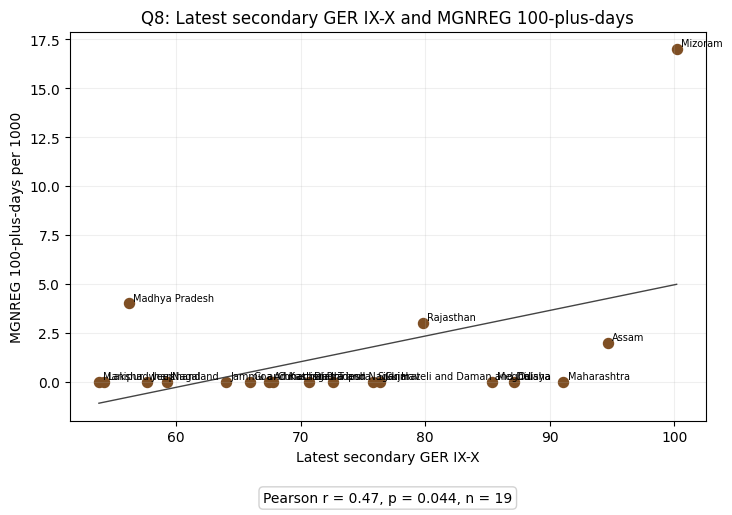

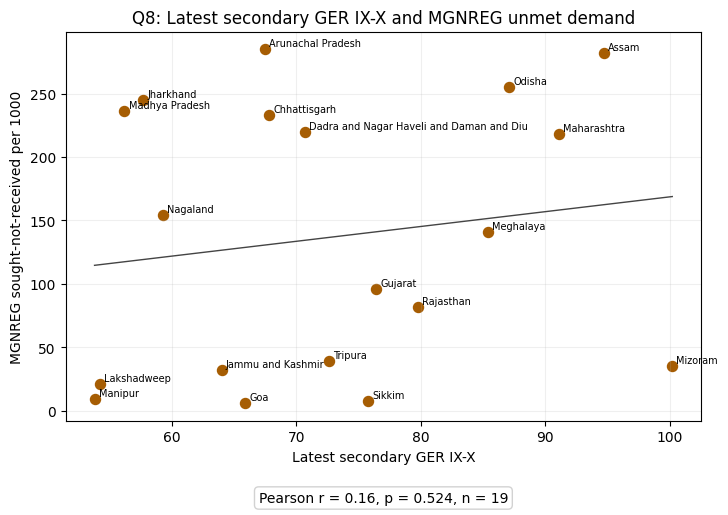

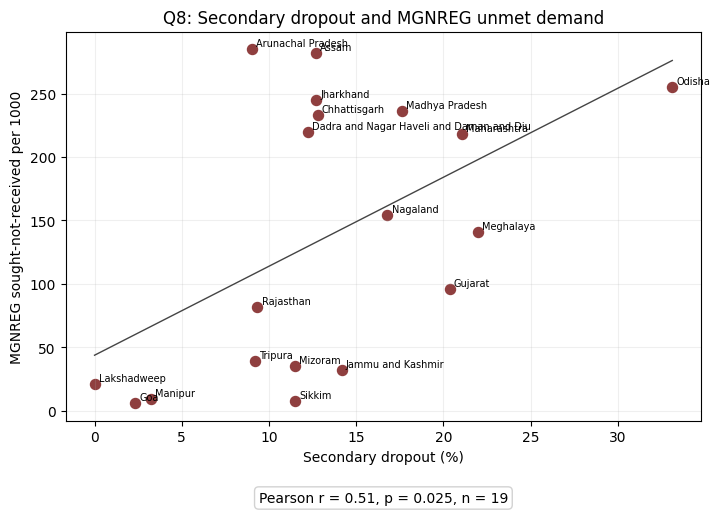

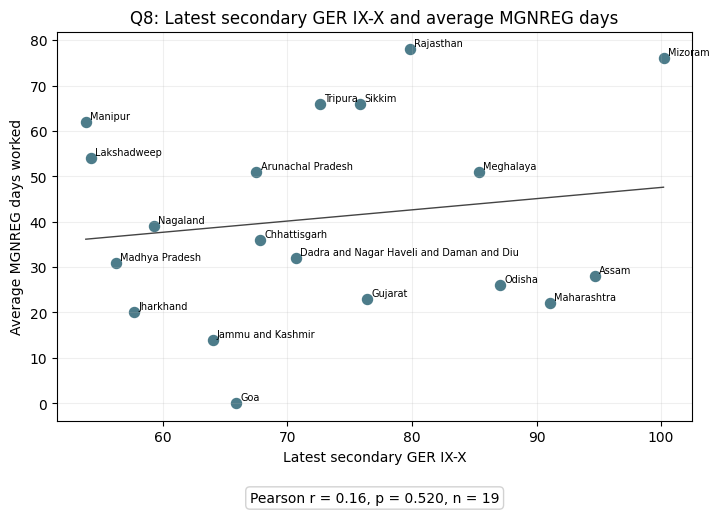

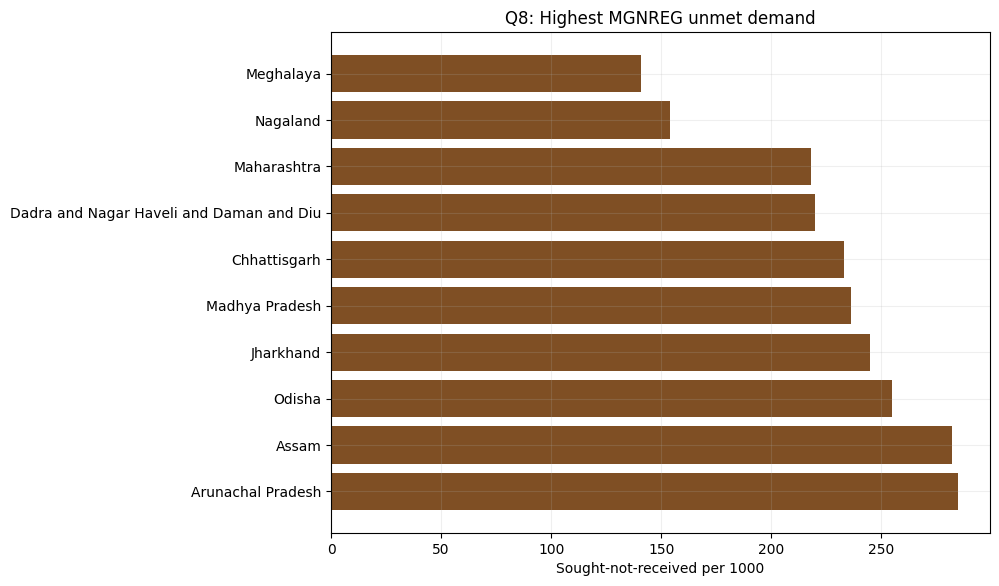

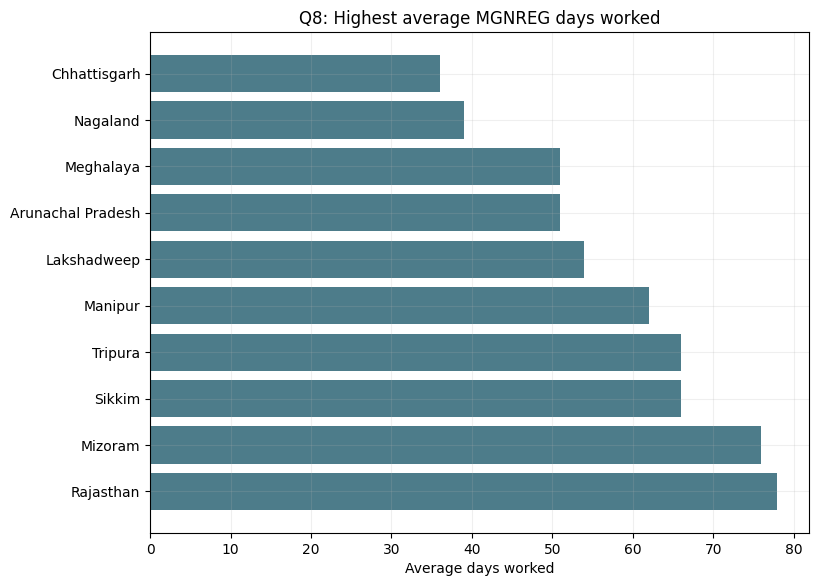

In [28]:
show_scatter(high_st, "ger_latest_secondary_total_clean", "mgnreg_work_100_plus_days_per_1000", "Q8: Latest secondary GER IX-X and MGNREG 100-plus-days", "Latest secondary GER IX-X", "MGNREG 100-plus-days per 1000", color="#7f4f24")
show_scatter(high_st, "ger_latest_secondary_total_clean", "mgnreg_sought_not_received_per_1000", "Q8: Latest secondary GER IX-X and MGNREG unmet demand", "Latest secondary GER IX-X", "MGNREG sought-not-received per 1000", color="#a65d03")
show_scatter(high_st, "dropout_secondary_pct", "mgnreg_sought_not_received_per_1000", "Q8: Secondary dropout and MGNREG unmet demand", "Secondary dropout (%)", "MGNREG sought-not-received per 1000", color="#8f3f3f")
show_scatter(high_st, "ger_latest_secondary_total_clean", "mgnreg_average_days_worked", "Q8: Latest secondary GER IX-X and average MGNREG days", "Latest secondary GER IX-X", "Average MGNREG days worked", color="#4d7c8a")
show_rank_bar(high_st, "mgnreg_sought_not_received_per_1000", "Q8: Highest MGNREG unmet demand", "Sought-not-received per 1000", ascending=False, top_n=10, color="#7f4f24")
show_rank_bar(high_st, "mgnreg_average_days_worked", "Q8: Highest average MGNREG days worked", "Average days worked", ascending=False, top_n=10, color="#4d7c8a")

In [29]:
high_ger_mgnreg = high_st[
    (high_st["ger_latest_secondary_total_clean"] >= high_st["ger_latest_secondary_total_clean"].median())
    & (
        (high_st["mgnreg_work_100_plus_days_per_1000"] >= high_st["mgnreg_work_100_plus_days_per_1000"].median())
        | (high_st["mgnreg_sought_not_received_per_1000"] >= high_st["mgnreg_sought_not_received_per_1000"].median())
    )
][[
    "state",
    "ger_latest_secondary_total_clean",
    "ger_latest_secondary_girls_clean",
    "gpi_secondary_clean",
    "dropout_secondary_pct",
    "mgnreg_work_100_plus_days_per_1000",
    "mgnreg_sought_not_received_per_1000",
    "mgnreg_average_days_worked",
    "employment_wpr_person_per_1000",
    "st_bpl_mean_pct",
]].sort_values(["mgnreg_work_100_plus_days_per_1000", "mgnreg_sought_not_received_per_1000"], ascending=[False, False])

high_ger_mgnreg

,state,ger_latest_secondary_total_clean,ger_latest_secondary_girls_clean,gpi_secondary_clean,dropout_secondary_pct,mgnreg_work_100_plus_days_per_1000,mgnreg_sought_not_received_per_1000,mgnreg_average_days_worked,employment_wpr_person_per_1000,st_bpl_mean_pct
18,Mizoram,100.2,105.8,1.1,11.48,17,35,76,461.0,NaN
4,Rajasthan,79.8,79.4,0.9,9.34,3,82,78,454.0,31.55
11,Assam,94.7,96.8,1.0,12.67,2,282,28,386.0,24.50
0,Odisha,87.1,89.6,1.0,33.12,0,255,26,504.0,51.60
10,Dadra and Nagar Haveli and Daman and Diu,70.7,76.1,1.0,12.21,0,220,32,NaN,NaN
3,Maharashtra,91.1,91.5,1.0,21.04,0,218,22,501.0,42.45
14,Meghalaya,85.4,98.0,1.3,21.99,0,141,51,462.0,NaN
8,Gujarat,76.4,75.9,1.0,20.35,0,96,23,465.0,33.30
9,Tripura,72.6,76.5,1.1,9.21,0,39,66,372.0,NaN
13,Sikkim,75.8,78.8,1.1,11.50,0,8,66,467.0,NaN


**Reading Q8:** the direct GER-to-MGNREG correlations are not strong enough to claim that schooling participation reduces livelihood dependence. The clearer pattern is that secondary dropout is associated with unmet MGNREG demand. That makes Q8 useful as a mismatch question: schooling participation alone is not enough; retention and local livelihood conditions matter.

## Q9. Does Gender Parity In Enrolment Translate Into Better Female Literacy And Work Outcomes?

A GPI value near 1 means parity in enrolment. This section uses the official ST Gender Parity Index dataset and asks whether enrolment parity lines up with later female literacy and work outcomes.

In [30]:
q9 = corr_frame(
    high_st,
    ["gpi_secondary_clean", "gpi_higher_secondary_clean", "ger_latest_secondary_girls_clean", "ger_latest_higher_secondary_girls_clean", "female_literacy_gap_pct"],
    ["tribe_weighted_literacy_female_pct", "employment_wpr_female_per_1000", "low_literacy_district_count"],
    "high_st_states",
)
q9

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,gpi_higher_secondary_clean,low_literacy_district_count,7,-0.9152,0.0038,0.9152
1,high_st_states,female_literacy_gap_pct,tribe_weighted_literacy_female_pct,19,-0.8947,0.0000,0.8947
2,high_st_states,gpi_secondary_clean,low_literacy_district_count,7,-0.7166,0.0700,0.7166
3,high_st_states,ger_latest_higher_secondary_girls_clean,low_literacy_district_count,7,-0.4876,0.2671,0.4876
4,high_st_states,gpi_secondary_clean,employment_wpr_female_per_1000,18,-0.3842,0.1155,0.3842
5,high_st_states,ger_latest_secondary_girls_clean,low_literacy_district_count,7,-0.3784,0.4026,0.3784
6,high_st_states,gpi_secondary_clean,tribe_weighted_literacy_female_pct,19,0.3677,0.1215,0.3677
7,high_st_states,female_literacy_gap_pct,employment_wpr_female_per_1000,18,0.3054,0.2178,0.3054
8,high_st_states,gpi_higher_secondary_clean,employment_wpr_female_per_1000,18,-0.2970,0.2313,0.2970
9,high_st_states,ger_latest_higher_secondary_girls_clean,tribe_weighted_literacy_female_pct,19,0.2876,0.2326,0.2876


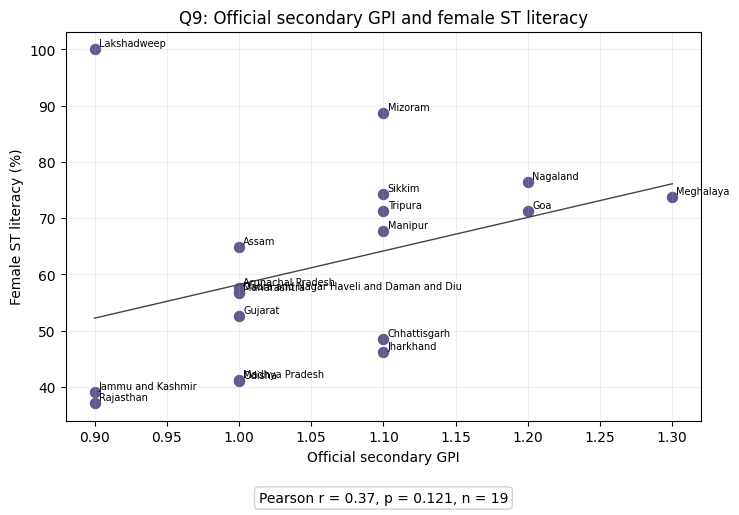

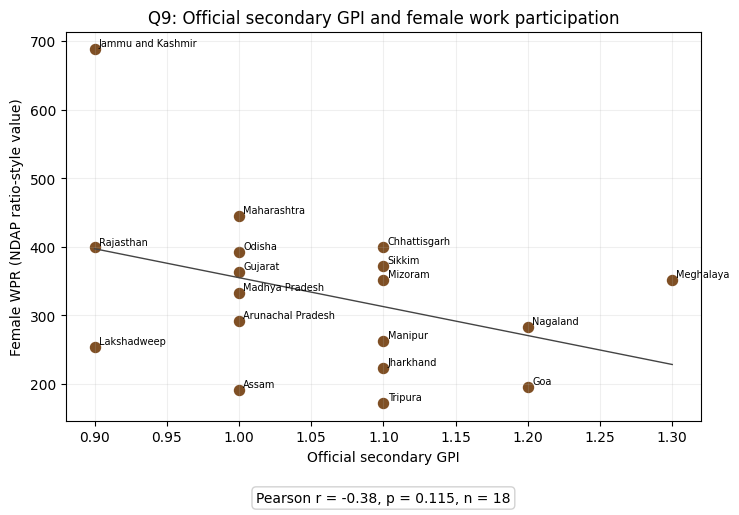

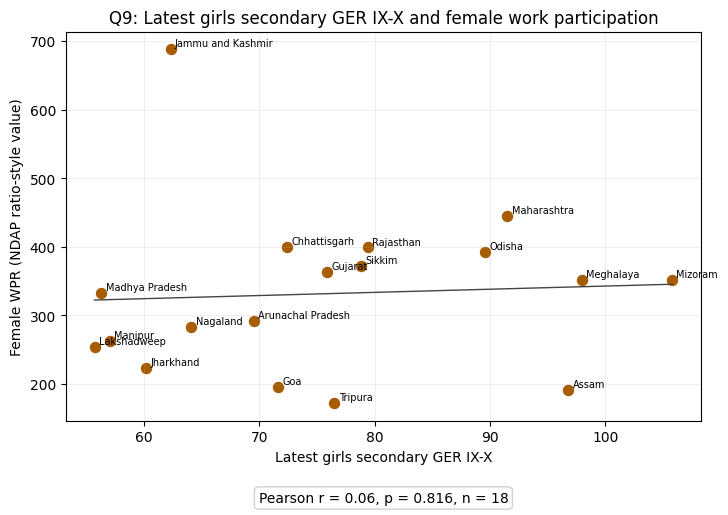

In [31]:
show_scatter(high_st, "gpi_secondary_clean", "tribe_weighted_literacy_female_pct", "Q9: Official secondary GPI and female ST literacy", "Official secondary GPI", "Female ST literacy (%)", color="#5f5b8f")
show_scatter(high_st, "gpi_secondary_clean", "employment_wpr_female_per_1000", "Q9: Official secondary GPI and female work participation", "Official secondary GPI", "Female WPR (NDAP ratio-style value)", color="#7f4f24")
show_scatter(high_st, "ger_latest_secondary_girls_clean", "employment_wpr_female_per_1000", "Q9: Latest girls secondary GER IX-X and female work participation", "Latest girls secondary GER IX-X", "Female WPR (NDAP ratio-style value)", color="#a65d03")

In [32]:
high_st[[
    "state",
    "gpi_secondary",
    "gpi_higher_secondary",
    "ger_latest_secondary_girls",
    "ger_latest_higher_secondary_girls",
    "tribe_weighted_literacy_female_pct",
    "female_literacy_gap_pct",
    "employment_wpr_female_per_1000",
    "low_literacy_district_count",
]].sort_values("gpi_secondary", ascending=False)

,state,gpi_secondary,gpi_higher_secondary,ger_latest_secondary_girls,ger_latest_higher_secondary_girls,tribe_weighted_literacy_female_pct,female_literacy_gap_pct,employment_wpr_female_per_1000,low_literacy_district_count
14,Meghalaya,1.3,1.4,98.0,47.4,73.762052,1.858609,352.0,NaN
15,Goa,1.2,1.0,71.6,72.1,71.292866,15.898644,195.0,NaN
5,Nagaland,1.2,1.2,64.1,43.4,76.381447,6.670924,283.0,NaN
9,Tripura,1.1,1.2,76.5,56.7,71.297697,15.027270,172.0,NaN
13,Sikkim,1.1,1.3,78.8,68.1,74.295249,10.761132,372.0,NaN
17,Manipur,1.1,1.0,57.0,32.6,67.792925,9.825213,263.0,NaN
18,Mizoram,1.1,1.1,105.8,58.6,88.664674,4.786373,352.0,NaN
6,Chhattisgarh,1.1,1.2,72.4,53.4,48.615475,20.909635,400.0,2.0
2,Jharkhand,1.1,1.1,60.2,37.2,46.163515,21.960463,223.0,6.0
8,Gujarat,1.0,1.1,75.9,46.8,52.678112,18.770234,363.0,1.0


**Reading Q9:** official enrolment parity does not automatically translate into female work participation. If GPI is near parity but female WPR remains weak, the state has a gendered education-livelihood mismatch rather than only an enrolment problem.

## Q10. Does Secondary Dropout Appear To Be A Stronger Warning Signal Of Poverty And Weak Labour Outcomes Than Literacy Alone?

In [33]:
q10 = compare_predictors(
    high_st,
    ["st_literacy_rate_pct", "dropout_secondary_pct"],
    [
        "st_bpl_mean_pct",
        "employment_wpr_person_per_1000",
        "employment_pu_person_per_1000",
        "mgnreg_sought_not_received_per_1000",
        "mgnreg_work_100_plus_days_per_1000",
    ],
)
q10

,outcome,stronger_predictor,n,pearson_r,pearson_p,runner_up,runner_up_abs_r
0,st_bpl_mean_pct,dropout_secondary_pct,9,0.5266,0.1453,st_literacy_rate_pct,0.0652
1,employment_wpr_person_per_1000,dropout_secondary_pct,18,0.5091,0.0309,st_literacy_rate_pct,0.4766
2,employment_pu_person_per_1000,st_literacy_rate_pct,18,0.6177,0.0063,dropout_secondary_pct,0.3165
3,mgnreg_sought_not_received_per_1000,st_literacy_rate_pct,18,-0.5271,0.0246,dropout_secondary_pct,0.5114
4,mgnreg_work_100_plus_days_per_1000,st_literacy_rate_pct,18,0.2882,0.2461,dropout_secondary_pct,0.0462


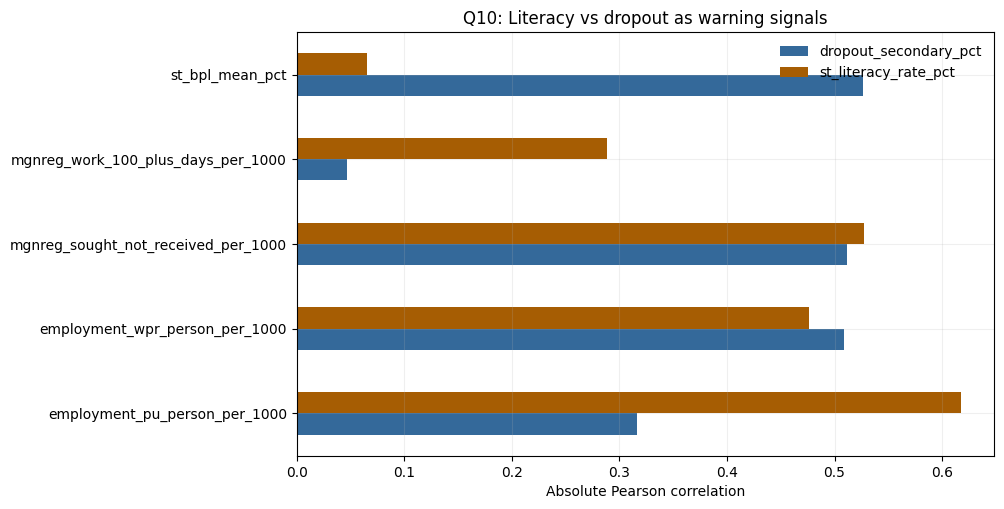

In [34]:
show_abs_correlation_compare(
    high_st,
    ["st_literacy_rate_pct", "dropout_secondary_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "mgnreg_sought_not_received_per_1000", "mgnreg_work_100_plus_days_per_1000"],
    "Q10: Literacy vs dropout as warning signals",
)

**Reading Q10:** secondary dropout is the stronger warning signal for ST poverty and MGNREG unmet demand, while ST literacy is stronger for the unemployment indicator. So the careful conclusion is not that dropout explains everything; it is that dropout adds information that literacy alone misses, especially for welfare and livelihood distress.

## Q11. Do High-ST-Share States Systematically Perform Worse, Or Do Outcomes Vary Substantially?

In [35]:
q7 = corr_frame(
    all_states,
    ["st_share_state_population_pct"],
    ["st_literacy_rate_pct", "dropout_secondary_pct", "st_bpl_mean_pct", "employment_wpr_person_per_1000"],
    "all_states",
)
q7

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,all_states,st_share_state_population_pct,st_literacy_rate_pct,27,0.6014,0.0009,0.6014
1,all_states,st_share_state_population_pct,st_bpl_mean_pct,18,0.5531,0.0173,0.5531
2,all_states,st_share_state_population_pct,dropout_secondary_pct,30,0.0842,0.6582,0.0842
3,all_states,st_share_state_population_pct,employment_wpr_person_per_1000,30,-0.0644,0.7352,0.0644


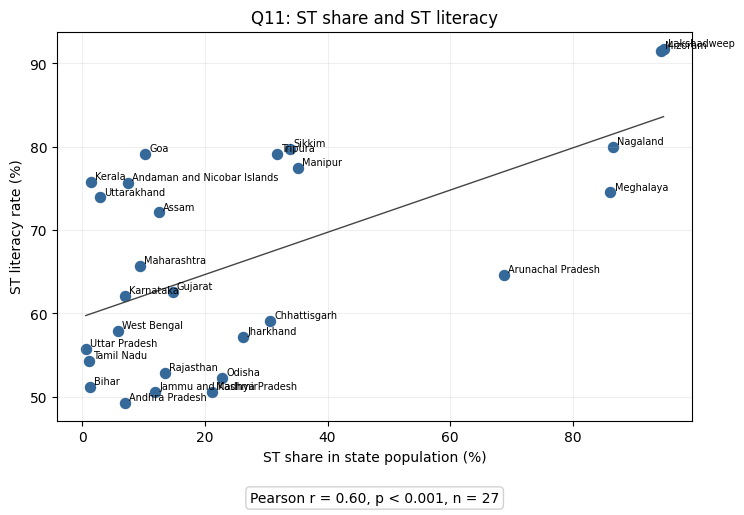

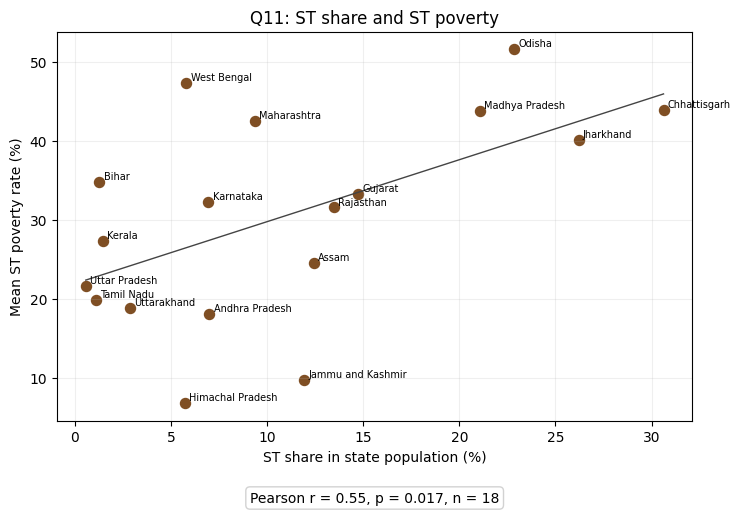

In [36]:
show_scatter(all_states, "st_share_state_population_pct", "st_literacy_rate_pct", "Q11: ST share and ST literacy", "ST share in state population (%)", "ST literacy rate (%)")
show_scatter(all_states, "st_share_state_population_pct", "st_bpl_mean_pct", "Q11: ST share and ST poverty", "ST share in state population (%)", "Mean ST poverty rate (%)", color="#7f4f24")

**Reading Q11:** concentration alone does not explain everything. High-ST states differ sharply in education and livelihood outcomes.

## Q12. Do States With High Concentrations Of ST Villages Show Different Education And Livelihood Outcomes?

Raw village counts are not directly comparable across states, so the notebook uses villages per 100,000 ST population.

In [37]:
q12 = corr_frame(
    high_st,
    [
        "villages_gt50_per_100k_st_pop",
        "villages_gt75_per_100k_st_pop",
        "villages_gt90_per_100k_st_pop",
        "villages_all_st_per_100k_st_pop",
    ],
    [
        "st_literacy_rate_pct",
        "literacy_gap_pct",
        "dropout_secondary_pct",
        "st_bpl_mean_pct",
        "mgnreg_sought_not_received_per_1000",
        "employment_wpr_person_per_1000",
        "employment_pu_person_per_1000",
    ],
    "high_st_states",
)
q12

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,villages_gt50_per_100k_st_pop,mgnreg_sought_not_received_per_1000,18,0.5025,0.0335,0.5025
1,high_st_states,villages_gt75_per_100k_st_pop,mgnreg_sought_not_received_per_1000,18,0.4503,0.0608,0.4503
2,high_st_states,villages_all_st_per_100k_st_pop,mgnreg_sought_not_received_per_1000,18,0.4232,0.0801,0.4232
3,high_st_states,villages_gt50_per_100k_st_pop,st_bpl_mean_pct,8,0.4109,0.3119,0.4109
4,high_st_states,villages_gt90_per_100k_st_pop,mgnreg_sought_not_received_per_1000,18,0.3997,0.1003,0.3997
5,high_st_states,villages_gt90_per_100k_st_pop,literacy_gap_pct,17,-0.3860,0.1259,0.3860
6,high_st_states,villages_gt75_per_100k_st_pop,st_bpl_mean_pct,8,0.3482,0.3980,0.3482
7,high_st_states,villages_gt75_per_100k_st_pop,literacy_gap_pct,17,-0.3416,0.1796,0.3416
8,high_st_states,villages_all_st_per_100k_st_pop,st_bpl_mean_pct,8,0.3185,0.4419,0.3185
9,high_st_states,villages_all_st_per_100k_st_pop,literacy_gap_pct,17,-0.3094,0.2269,0.3094


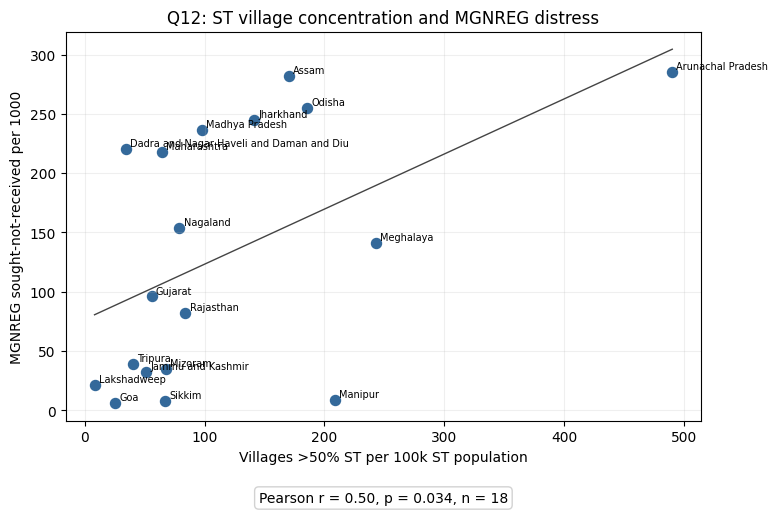

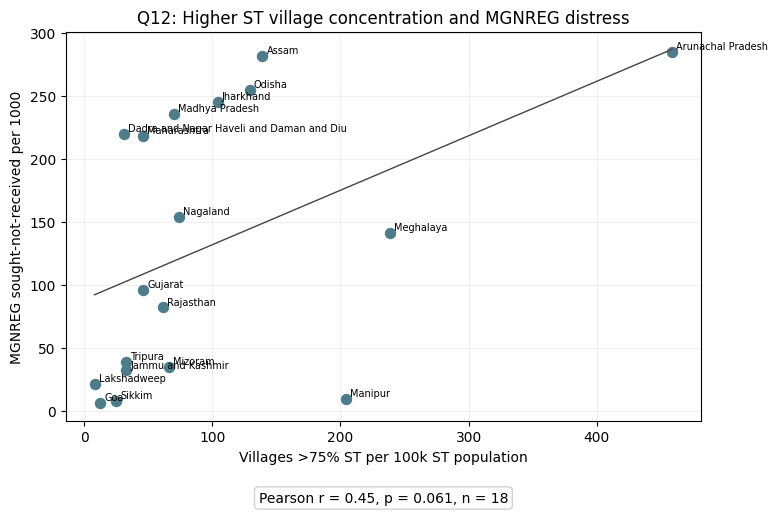

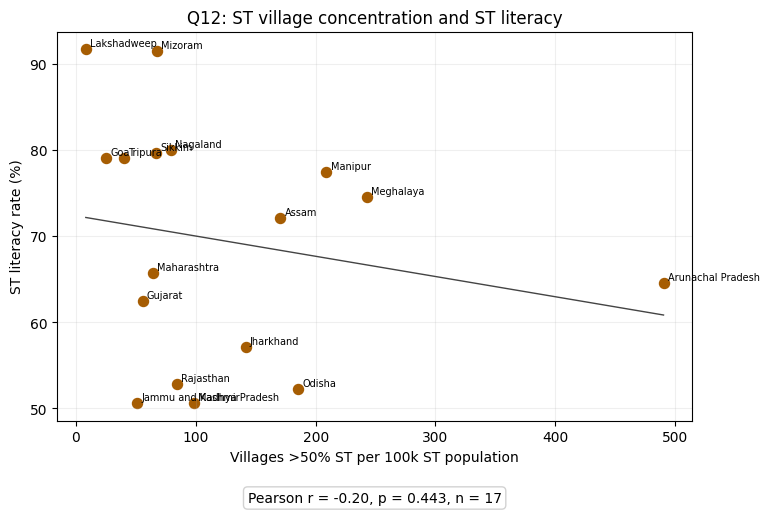

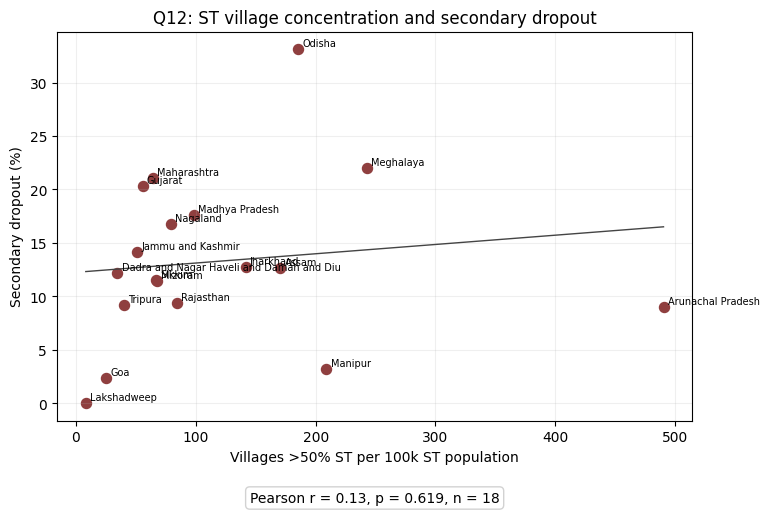

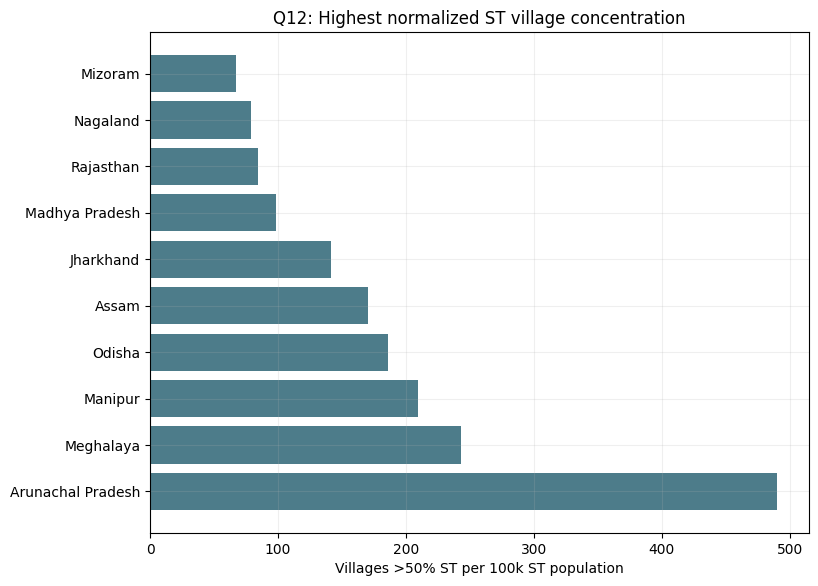

In [38]:
show_scatter(high_st, "villages_gt50_per_100k_st_pop", "mgnreg_sought_not_received_per_1000", "Q12: ST village concentration and MGNREG distress", "Villages >50% ST per 100k ST population", "MGNREG sought-not-received per 1000")
show_scatter(high_st, "villages_gt75_per_100k_st_pop", "mgnreg_sought_not_received_per_1000", "Q12: Higher ST village concentration and MGNREG distress", "Villages >75% ST per 100k ST population", "MGNREG sought-not-received per 1000", color="#4d7c8a")
show_scatter(high_st, "villages_gt50_per_100k_st_pop", "st_literacy_rate_pct", "Q12: ST village concentration and ST literacy", "Villages >50% ST per 100k ST population", "ST literacy rate (%)", color="#a65d03")
show_scatter(high_st, "villages_gt50_per_100k_st_pop", "dropout_secondary_pct", "Q12: ST village concentration and secondary dropout", "Villages >50% ST per 100k ST population", "Secondary dropout (%)", color="#8f3f3f")
show_rank_bar(high_st, "villages_gt50_per_100k_st_pop", "Q12: Highest normalized ST village concentration", "Villages >50% ST per 100k ST population", ascending=False, top_n=10, color="#4d7c8a")

**Reading Q12:** after normalizing by ST population, village concentration is mainly connected to MGNREG unmet demand, not strongly to literacy or dropout. This makes it useful as a spatial livelihood-distress signal, but it should be treated as secondary evidence rather than the central education finding.

## Q13. Are There Gender-Specific Disadvantages Hidden Behind State Averages?

In [39]:
q9 = corr_frame(
    high_st,
    ["female_literacy_gap_pct", "tribe_weighted_literacy_female_pct"],
    ["employment_wpr_female_per_1000", "st_bpl_mean_pct", "low_literacy_district_count"],
    "high_st_states",
)
q9

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,tribe_weighted_literacy_female_pct,low_literacy_district_count,7,-0.8764,0.0096,0.8764
1,high_st_states,tribe_weighted_literacy_female_pct,employment_wpr_female_per_1000,18,-0.4623,0.0534,0.4623
2,high_st_states,female_literacy_gap_pct,employment_wpr_female_per_1000,18,0.3054,0.2178,0.3054
3,high_st_states,female_literacy_gap_pct,low_literacy_district_count,7,0.2710,0.5566,0.2710
4,high_st_states,female_literacy_gap_pct,st_bpl_mean_pct,9,0.0504,0.8975,0.0504
5,high_st_states,tribe_weighted_literacy_female_pct,st_bpl_mean_pct,9,-0.0382,0.9222,0.0382


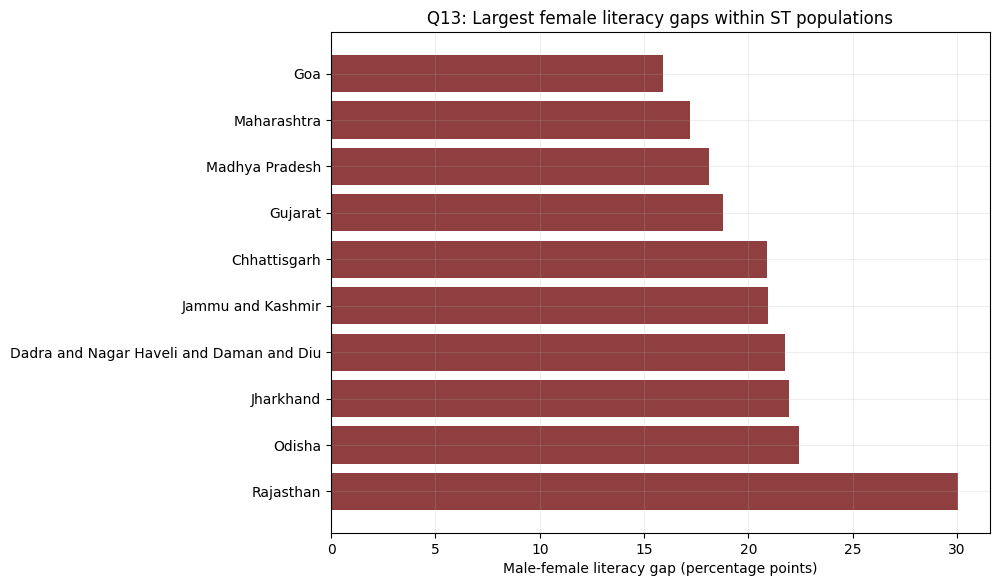

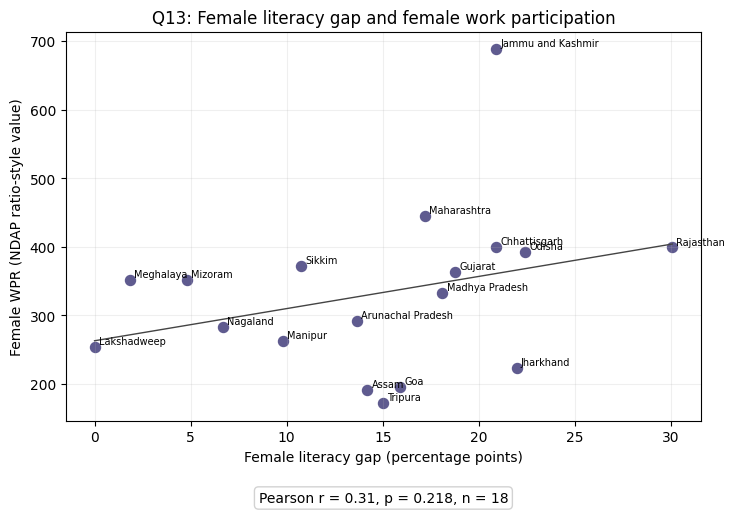

In [40]:
show_rank_bar(high_st, "female_literacy_gap_pct", "Q13: Largest female literacy gaps within ST populations", "Male-female literacy gap (percentage points)", ascending=False, top_n=10, color="#8f3f3f")
show_scatter(high_st, "female_literacy_gap_pct", "employment_wpr_female_per_1000", "Q13: Female literacy gap and female work participation", "Female literacy gap (percentage points)", "Female WPR (NDAP ratio-style value)", color="#5f5b8f")

In [41]:
high_st[[
    "state",
    "tribe_weighted_literacy_male_pct",
    "tribe_weighted_literacy_female_pct",
    "female_literacy_gap_pct",
    "low_literacy_district_count",
    "employment_wpr_female_per_1000",
]].sort_values("female_literacy_gap_pct", ascending=False).head(10)

,state,tribe_weighted_literacy_male_pct,tribe_weighted_literacy_female_pct,female_literacy_gap_pct,low_literacy_district_count,employment_wpr_female_per_1000
4,Rajasthan,67.200036,37.133955,30.066081,11.0,399.0
0,Odisha,63.441680,41.039995,22.401685,6.0,392.0
2,Jharkhand,68.123978,46.163515,21.960463,6.0,223.0
10,Dadra and Nagar Haveli and Daman and Diu,78.700355,56.934504,21.765852,NaN,NaN
7,Jammu and Kashmir,60.082673,39.166195,20.916478,15.0,688.0
6,Chhattisgarh,69.525111,48.615475,20.909635,2.0,400.0
8,Gujarat,71.448346,52.678112,18.770234,1.0,363.0
1,Madhya Pradesh,59.296080,41.195279,18.100800,11.0,332.0
3,Maharashtra,73.863914,56.660439,17.203475,NaN,445.0
15,Goa,87.191510,71.292866,15.898644,NaN,195.0


**Reading Q13:** the strongest gender result is descriptive: Rajasthan, Odisha, Jharkhand, Jammu and Kashmir, and Madhya Pradesh show particularly large female literacy disadvantages.

## Policy Synthesis

The most useful policy story from this notebook is:

- **Odisha and Madhya Pradesh:** compound education and livelihood distress.
- **Jharkhand and Chhattisgarh:** livelihood distress and MGNREG-linked vulnerability remain central.
- **Maharashtra and Gujarat:** access or GER alone is not enough because retention and poverty concerns remain.
- **Rajasthan and Jammu and Kashmir:** literacy inequality and gender disadvantage deserve special targeting.
- **Assam, Nagaland, Arunachal Pradesh, Tripura:** education-livelihood mismatch patterns suggest labour-side or household-distress constraints even when education indicators are not the weakest.

In [42]:
policy_profiles = pd.read_csv(OUTPUTS / "eda" / "tables" / "state_policy_recommendations.csv")
policy_profiles[[
    "state",
    "overall_priority_rank",
    "policy_priority_category",
    "evidence_flags",
    "recommended_policy_focus",
]].head(12)

,state,overall_priority_rank,policy_priority_category,evidence_flags,recommended_policy_focus
0,Odisha,1.0,High education disadvantage and high economic vulnerability,low ST literacy (52.20%); large literacy gap (20.60 pp); high secondary dropout (33.12%); low female literacy (41.04%); high ST poverty (51.60%); high unmet MGNREG demand (255 ...,"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
1,Madhya Pradesh,3.0,High education disadvantage and high economic vulnerability,low ST literacy (50.60%); large literacy gap (18.80 pp); high secondary dropout (17.60%); low female literacy (41.20%); high ST poverty (43.80%); high unmet MGNREG demand (236 ...,"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
2,Jharkhand,6.0,Economic vulnerability priority,low ST literacy (57.10%); low female literacy (46.16%); weak WPR (375 per 1000); high unmet MGNREG demand (245 per 1000); 6 low-female-literacy district(s); many >50% ST villag...,"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Add female literacy interventions: residential schooling, women teachers, safety, san..."
3,Maharashtra,7.0,High education disadvantage and high economic vulnerability,large literacy gap (16.60 pp); high secondary dropout (21.04%); many >50% ST villages (6738),"Target the ST-general population literacy gap with ST-focused school support and tracking; Strengthen secondary retention through hostels, transport, scholarships, and transiti..."
4,Rajasthan,9.0,Education disadvantage priority,low ST literacy (52.80%); large literacy gap (13.30 pp); low female literacy (37.13%); 11 low-female-literacy district(s); many >50% ST villages (7763),"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
5,Nagaland,10.0,Economic vulnerability priority,high secondary dropout (16.79%); weak WPR (385 per 1000),"Strengthen secondary retention through hostels, transport, scholarships, and transition support; Connect upper-secondary schooling with local skills, placement, and public empl..."
6,Chhattisgarh,11.0,Economic vulnerability priority,low ST literacy (59.10%); low female literacy (48.62%); high ST poverty (43.90%); high unmet MGNREG demand (233 per 1000); 2 low-female-literacy district(s),"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Add female literacy interventions: residential schooling, women teachers, safety, san..."
7,Jammu and Kashmir,12.0,Education disadvantage priority,low ST literacy (50.60%); large literacy gap (16.60 pp); low female literacy (39.17%); 15 low-female-literacy district(s),"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
8,Gujarat,13.0,Monitor / comparatively lower priority,large literacy gap (15.60 pp); high secondary dropout (20.35%); 1 low-female-literacy district(s),"Target the ST-general population literacy gap with ST-focused school support and tracking; Strengthen secondary retention through hostels, transport, scholarships, and transiti..."
9,Tripura,15.0,Economic vulnerability priority,weak WPR (372 per 1000),"Connect upper-secondary schooling with local skills, placement, and public employment pathways"


## Database Requirement

The project guideline requires database storage and querying. The project uses SQLite with cleaned tables, a final state analysis table, and a sparse state-year fact table.

In [43]:
with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query(
        "select name from sqlite_master where type='table' order by name", conn
    )
    top_priority_query = pd.read_sql_query(
        '''
        select state, overall_priority_rank, overall_priority_score, policy_priority_category
        from state_analysis_dataset
        where is_high_st_share_state = 1
        order by overall_priority_score desc
        limit 10
        ''',
        conn,
    )

display(tables)
display(top_priority_query)

,name
0,demographics_st
1,dropout_st
2,employment_st
3,enrolment_st
4,fact_state_year_sparse
5,ger_st
6,ger_st_latest
7,gpi_st
8,high_st_share
9,household_type_rural


,state,overall_priority_rank,overall_priority_score,policy_priority_category
0,Odisha,1.0,0.633817,High education disadvantage and high economic vulnerability
1,Madhya Pradesh,3.0,0.574014,High education disadvantage and high economic vulnerability
2,Jharkhand,6.0,0.506882,Economic vulnerability priority
3,Maharashtra,7.0,0.505488,High education disadvantage and high economic vulnerability
4,Rajasthan,9.0,0.454222,Education disadvantage priority
5,Nagaland,10.0,0.435187,Economic vulnerability priority
6,Chhattisgarh,11.0,0.423803,Economic vulnerability priority
7,Jammu and Kashmir,12.0,0.409903,Education disadvantage priority
8,Gujarat,13.0,0.408766,Monitor / comparatively lower priority
9,Tripura,15.0,0.380164,Economic vulnerability priority


## Final Takeaway

This project is strongest when framed as:

**How do differences in ST educational outcomes relate to livelihood distress, and what policy package does each state type need?**

That keeps the analysis relationship-based, policy-relevant, and honest about where the data are strongest.